# NFL Contracts Predictions Capstone pt 2.
## Introduction Review


---


### Research Question
  Can historical on-field performance data reliably predict the values for NFL Offensive position players' (QB, RB, WR, TE) next contract.

### Business Understanding
  The NFL salary cap is a year by year puzzle that can make or break the success of an NFL Franchise. Producing a model that is able to understand the fair market value for player contracts, given their recent and career production on the field will allow teams and players alike to better get a grasp of what makes sense and what is actually possible.

### Data Sources
  The data obtained for this analysis come from the nflverse online Github Repository. This is a collection of curated NFL data scraped from the web to compile all significant data needed for analysis of the NFL. Some sources include OvertheCap, NFL API's and feeds from major sports reporting agencies.

### Data Structure
  I will be loading Data involving individual player statistics, overall team statistics, Contract data and schedule data. I will review all the data and engineer different features to include in my end model. Additionally, I will test different dataframes with data splits to ultimately decide which features hold the biggest level of significance.  

### Expected Results
  I anticipate being able to create a model that will take in key player production metrics and success that will predict appropriate contract values within an error of 3 million per year average.


---


# Model Exploration Approach
---
Following our initial Data Analysis, I will utilize the dataframes that were cleaned up in our original notebook 'NFL Initial Data Analysis' to explore features, model creation and model tuning to better answer our question on whether historical on-field performance data can reliably predict NFL contracts for offensive players, specifically QB, RB, WR & TE.

The end goal is to identify the factors that influence NFL contract values for offensive skill positions, and the analysis of such will proceed in three main stages:


1.   Establish Baseline models using cumulative career production at each contract event.
2.   Evaluate impact of regular and postseason split data on predictive performance.
3.   Evaluate the impact of efficiency metrics on predictive performance.

Additionally, all position and position specific models will be assessed to determine whehter contract valuation differs significantly by position.







In [272]:
# @title Library & Function Imports
%%capture
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error, make_scorer
import warnings
import time
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)

### DataFrame Imports

---



In [2]:
# @title Imports of DataFrames from first notebook.
# Begin by importing all data that was cleaned up and raw versions handled
# in previous Notebook.
# Note - not all data will be used, some will be altered.

# Cleaned Contracts Data Frame
contract_final = pd.read_csv('data/contracts_final.csv')

# Player Stats Season Totals
tot_plyr_sts = pd.read_csv('data/total_player_stats.csv')

# Team Season Stats Totals
tot_tm_sts = pd.read_csv('data/total_team_stats.csv')

# QB specific W/L records
tot_qb_rcds = pd.read_csv('data/total_qb_records.csv')

# Team W/L records per season
tot_tm_rcds = pd.read_csv('data/total_team_records.csv')

# Raw Player Stats filtered to offensive positions
player_stats_filtered = pd.read_csv('data/filtered_player_stats.csv')

# Raw Contracts data with key colunns
filtered_contracts = pd.read_csv('data/filtered_contract.csv')

# Raw Team Stats
team_stats = pd.read_csv('data/team_stats.csv')

# Raw QB/Team Records
combined = pd.read_csv('data/records.csv')

### Functions Utilized in Notebook.

---


In [3]:
# @title Stat Name Abbreviation Dictionary Code Block
# Create a dictionary for minimizing stat names in dataframe as well as reverse
# Dictionary to be utilized for extending column names for legebility.
new_stat_names = {'completions': 'cmp',
                'attempts' : 'att',
                'passing_yards': 'p_yds',
                'passing_tds': 'p_tds',
                'passing_interceptions': 'int',
                'sacks_suffered': 'sacked',
                'passing_air_yards' : 'p_airyds',
                'passing_yards_after_catch': 'p_yac',
                'passing_first_downs' : 'p_1sts',
                'passing_epa' : 'p_epa',
                'carries' : 'carr',
                'rushing_yards': 'ru_yds',
                'rushing_tds' : 'ru_tds',
                'rushing_fumbles': 'ru_fumb',
                'rushing_first_downs' : 'ru_1sts',
                'rushing_epa': 'ru_epa',
                'receptions' : 'rec',
                'targets' : 'tgts',
                'receiving_yards' : 'rec_yds',
                'receiving_tds' : 'rec_tds',
                'receiving_fumbles' : 'rec_fumb',
                'receiving_air_yards' : 'rec_airyds',
                'receiving_yards_after_catch': 'rec_yac',
                'receiving_first_downs' : 'rec_1sts',
                'receiving_epa': 'rec_epa'}

# Reverse Dictionary for Stat Abbrevitaions
reverse_stat_dictionary = {v: k for k, v in new_stat_names.items()}

In [4]:
# @title Functions for the creation of Preproccessor and Model Pipelines

# Function for the creation of a preprocessor for data.
def create_preprocessor(cat_fts,num_fts):
  num_transformer = Pipeline(steps = [
      ('imputer', SimpleImputer(strategy = 'mean')),
      ('scaler', StandardScaler())
  ])
  return ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown= 'ignore'), cat_fts),
        ('num', num_transformer, num_fts)
        ])

# Function that creates model pipeline
def create_model_pipeline(model, cat_fts, num_fts):
  return Pipeline([
    ('preprocessor', create_preprocessor(cat_fts, num_fts)),
    ('regressor', model)
  ])


In [5]:
# @title Model Experiments Function
#Creating a function for running model experiments.
def run_model_experiments(data, target, features, model_dict, test_size=0.2,random_state=42):
  # Seperate data between features and target
  X = data[features]
  y = data[target]

  # Establish a test / train split.
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
  # Track results, trained models and store predictions for analysis.
  results = []
  trained_models = {}
  prediction_store = {}
  # Loop through dictionary of models given.
  for model_name, pipeline in model_dict.items():
    current_pipeline = clone(pipeline)
    # Time training of Model
    start = time.time()
    current_pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    # Gather predictions of models.
    train_preds = current_pipeline.predict(X_train)
    test_preds = current_pipeline.predict(X_test)

    #RMSE
    train_rmse = root_mean_squared_error(y_train, train_preds)
    test_rmse = root_mean_squared_error(y_test, test_preds)

    #MAE
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)

    #R2
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    results.append({
        'Model': model_name,
        'Train_time': train_time,
        'Train_rmse': train_rmse,
        'Test_rmse': test_rmse,
        'Train_mae': train_mae,
        'Test_mae': test_mae,
        'Train_r2': train_r2,
        'Test_r2': test_r2,})

    trained_models[model_name] = current_pipeline
    prediction_store[model_name] = pd.DataFrame({
        'actual' : y_test,
        'predicted' : test_preds
    })
  results_df = pd.DataFrame(results)
  results_df = results_df.sort_values(by='Test_rmse', ascending=True)
  return {
      'results' : results_df,
      'models': trained_models,
      'predictions' : prediction_store
  }

In [6]:
# @title Feature Extractor / Plotting Functions for Pipelines
linear_models = ('Linear Regression', 'Ridge', 'Lasso', 'ElasticNet')
def feature_extractor(model_name, pipeline):
  feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
  if model_name in linear_models:
    values = pipeline.named_steps['regressor'].coef_
  else:
    values = pipeline.named_steps['regressor'].feature_importances_
  df = pd.DataFrame({
      'feature': feature_names,
      'importance': values
  })
  return df.sort_values(by='importance', ascending=False)

# Function for the plotting of Best/Worse Features for a Pipeline.
def plot_fts(df, model_name, ax, top = True, bottom = True,  n=10):
  # Best and Worse N Features
  if top and bottom:
    top_feats = pd.concat([df.head(n), df.tail(n)])
    midpoint = ((len(top_feats) + 1 ) // 2 ) - 0.5
    colors = ['lightcoral' if c < 0 else 'lightgreen' for c in top_feats['importance']]
    ax.barh(top_feats['feature'], top_feats['importance'], color = colors, edgecolor= 'none')
    ax.axhline(y = midpoint, color = 'black', linestyle = '--', linewidth = 1, label = 'Top/Bottom divider')
    ax.set_title(f"{model_name} - Top / Worst {n} Features")
  # Best N Features
  if top and not bottom:
    top_feats = df.head(n)
    colors = ['lightcoral' if c < 0 else 'lightgreen' for c in top_feats['importance']]
    ax.barh(top_feats['feature'], top_feats['importance'], color = colors, edgecolor= 'none')
    ax.set_title(f"{model_name} - Top {n} Features")
  # Worst N Features
  if bottom and not top:
    bottom_feats = df.tail(n)
    colors = ['lightcoral' if c < 0 else 'lightgreen' for c in bottom_feats['importance']]
    ax.barh(bottom_feats['feature'], bottom_feats['importance'], color = colors, edgecolor= 'none')
    ax.set_title(f"{model_name} - Worst {n} Features")
  ax.set_xlabel("Importance / Coefficient")
  ax.set_ylabel("Feature")
  ax.tick_params(axis='both', labelsize = '8')

In [7]:
# @title Table for Feature Summary on each model. .
# This will help us select the best features for our final dataset we will optimize

def feature_ranking(exp_results):
  ranking_table = None
  # Loop through Results
  for model in exp_results['results']['Model']:
    fts = feature_extractor(model, exp_results['models'][model]).copy()
    # Rank Features (1 = Most Important)
    fts['Rank'] = (fts['importance'].abs().rank(ascending = False, method = 'min'))
    # Rename Column Names
    fts = (fts[['feature','Rank']].rename(columns = {'Rank': model}))
    if ranking_table is None:
      ranking_table = fts
    else:
      ranking_table = ranking_table.merge(fts, on = 'feature', how = 'outer')
  ranking_table['Average Rank'] = ranking_table[exp_results['results']['Model']].mean(axis = 1)
  return ranking_table.sort_values(by = 'Average Rank').reset_index(drop = True)

def feature_importance(exp_results):
  importance_table = None
  for model in exp_results['results']['Model']:
    fts = feature_extractor(model, exp_results['models'][model]).copy()
    # Noramlize using absolute importance
    fts['Normalized Importance'] = fts['importance'].abs() / fts['importance'].abs().max()

    fts = (fts[['feature','Normalized Importance']].rename(columns = {'Normalized Importance': model}))
    if importance_table is None:
      importance_table = fts
    else:
      importance_table = importance_table.merge(fts, on = 'feature', how = 'outer')
  importance_table['Average Importance'] = importance_table[exp_results['results']['Model']].mean(axis = 1)
  return importance_table.sort_values(by = 'Average Importance', ascending = False).reset_index(drop = True)

def build_feature_summary(exp_results):
  summary = feature_ranking(exp_results).merge(feature_importance(exp_results)[['feature','Average Importance']], on = 'feature', how = 'outer')
  return summary.sort_values(['Average Rank','Average Importance'], ascending= [True, False]).reset_index(drop = True)

In [8]:
# @title Function for Merge of Stats/Contract Dataframe outline
# This will be utilized for testing different data splits on models.
# Function returns a Dataframe where each contract event has all player stats
# data prior to the contract signing.

def stat_contracts_merge(stat_df):
  # Create Dataframe with subset of data.
  contract_subset = contract_final[['player','position','team','exp','year_signed','value','apy','contract_event','draft_year','contract_id']].copy()

  # Inner merge contract subset with player stats and records
  # This will create a new Dataframe where each contract event will have all the stats available
  # for each player.
  merged = stat_df.merge(contract_subset, on = ['player','position'], how = 'inner')

  # Filter the data for player stats prior to the year contract was signed,
  # removing stats during or after contracts.
  merged = merged[merged['year_signed'] > merged['season']]

  # Filter out older players who have names that match recent players
  merged = merged[merged['season'] >= merged['draft_year']]

  # Define the desired order of columns explicitly
  start_cols = ['player_id', 'player', 'position', 'season', 'team_x']
  contract_info_cols = ['team_y','year_signed','exp', 'value','apy','contract_event', 'draft_year', 'contract_id']

  # Get all other columns, excluding those already in start_cols or contract_info_cols
  remaining_cols = [col for col in merged.columns if col not in (set(start_cols) | set(contract_info_cols))]

  # Assemble the new column order
  col_swap = start_cols + contract_info_cols + remaining_cols

  # Establish new DF
  return merged[col_swap]


In [9]:
#@title Function for Aggregating Stats in Contract/Stats DF
# This function utilizes the contract_final DF and
def contract_stat_agg(stat_df):
  # Aggregation function for player Stats data with Contract DF

  # Merge Contract and Playoff Split Data
  tmp_contracts_sts = stat_contracts_merge(stat_df)

  # Seperate Columns between id/ stats
  id_cols = ['player_id', 'player','position','season','team']

  stat_cols = [
      col for col in stat_df.columns if col not in id_cols
  ]

  # Also use specific addition and average metrics leading up to contract event.
  sum_agg = {col: 'sum' for col in stat_cols}

  # Create Dataframes given all of the aggregations.
  sums_agg = tmp_contracts_sts.groupby('contract_id').agg(sum_agg)

  # Merge the data frames with the original contracts data frame on contract_id.
  # Giving us all aggregations of stats prior to each contract event.
  sums_agg.reset_index()
  tmp_contracts_sums = contract_final.merge(sums_agg, on='contract_id', how='inner')

  # Removing unnecessary ID columns. Potential targets identified.
  id_cols_drp =['player','team','year_signed','draft_year','years','value', 'guaranteed', 'apy_cap_pct','draft_team','contract_type','prev_team','contract_id']

  # Drop Unneeded ID Columns & return DF

  return tmp_contracts_sums.drop(columns=id_cols_drp)

# **How well can raw career production explain contract value?**
Does career production leading up to a contract event provide enough context to accurately predict contract values?

## Baseline Model


---



The initial experiment utilized cumulative career production metrics, features that are commonly used when discussing player value overall. This will establish a benchmark for use to compare future feature engineering efforts.

In [10]:
# @title Baseline Player Stat Aggregations
# Utilization of Total Player Stats and Records Leading up to a Contract Event
cntrct_sum = contract_stat_agg(tot_plyr_sts)

In [11]:
# @title Basline Model - Linear Regression
# Seperate Features for Modeling of All data
base_cat_fts = ['position','contract_event','exp']
base_num_fts = [col for col in cntrct_sum.columns if col not in set(base_cat_fts + ['apy'])]

# Baseline Model Dictionary
base_model = {
    'Linear Regression' : create_model_pipeline(LinearRegression(), base_cat_fts, base_num_fts)
}

In [12]:
# Baseline Model Experiments (Stat Totals leading to Contract Event)
base_fts = base_cat_fts + base_num_fts
b_results = run_model_experiments(cntrct_sum, 'apy', base_fts, base_model)
# Piecing all data together for easier visualization
b_results['results']

,Model,Train_time,Train_rmse,Test_rmse,Train_mae,Test_mae,Train_r2,Test_r2
0,Linear Regression,0.024717,4.126922,4.41308,2.344497,2.359665,0.510663,0.404632


In [13]:
# Record and track baseline Metrics for future model comparisons.
baseline_train_time = b_results['results']['Train_time'].mean()
baseline_test_rmse = b_results['results']['Test_rmse'].mean()
baseline_test_mae = b_results['results']['Test_mae'].mean()
baseline_test_r2 = b_results['results']['Test_r2'].mean()

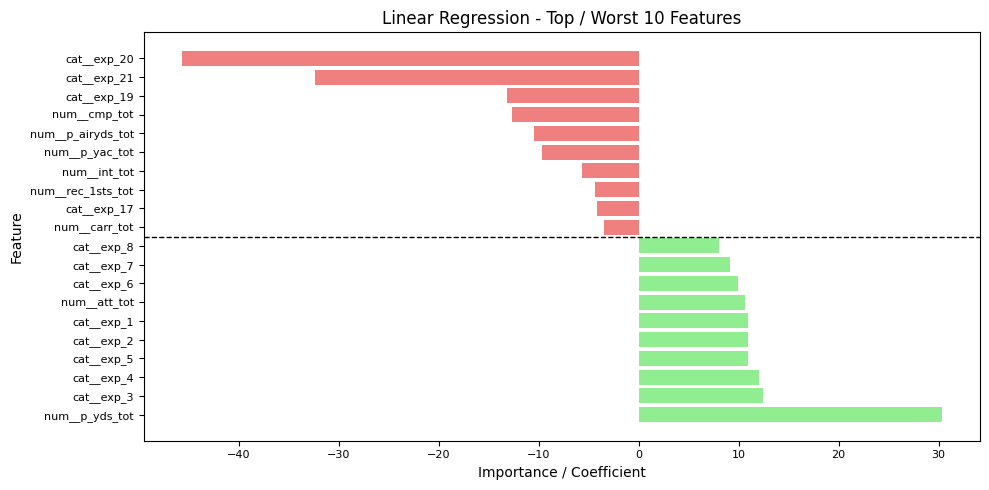

In [14]:
# Visualize Feature Significance for Model fed all Data.
all_stat = feature_extractor('Linear Regression', b_results['models']['Linear Regression'])
fig, ax = plt.subplots(figsize = (10,5))
plot_fts(all_stat, 'Linear Regression', ax)
plt.tight_layout()
plt.show()

## Baseline Model Findings  


---


Our basline model was able to establish a Test RMSE score of ~4.4 million, which is fairly close to my expected results of being able to predict within a 3 million error.  

However, when exploring feature significance, we noticed that the experience categorical features fed into the model were dominant in the top features.  

 Initially I believed experience was correctly set as a categorical feature, however given the number of occurences I realize that is no longer the case.  
 To address this, we will re-run the baseline with experience no longer being a categorical feature and added to the numerical features.

## Baseline Model v2

---



In [15]:
# Removal of "EXP" as a categorical feature.
CATEGORICAL_FEATURES = ['position','contract_event']
def feature_splits(df, cats = CATEGORICAL_FEATURES):
  cats = CATEGORICAL_FEATURES
  return cats, [col for col in df.columns if col not in (set(cats + ['apy']))]

In [16]:
# @title Basline Model - Linear Regression without Experience as catergorical feature
# Seperate Features for Modeling of All data
b2_cat_fts, b2_num_fts = feature_splits(cntrct_sum)

# Create Pipelines
b2_models = {
    'Linear Regression' : create_model_pipeline(LinearRegression(), b2_cat_fts, b2_num_fts)
}

b2_fts = b2_cat_fts + b2_num_fts

In [17]:
b2_results = run_model_experiments(cntrct_sum, 'apy', b2_fts, b2_models)
b2_results['results']

,Model,Train_time,Train_rmse,Test_rmse,Train_mae,Test_mae,Train_r2,Test_r2
0,Linear Regression,0.038603,4.360465,4.614963,2.505803,2.528768,0.453713,0.348914


In [18]:
# Creating Combined results Dataframe, adding additional column for identification of results.
b_results['results']['EXP Type'] = 'Categorical'
b2_results['results']['EXP Type'] = 'Numerical'
comparison_results = pd.concat([b_results['results'], b2_results['results']])

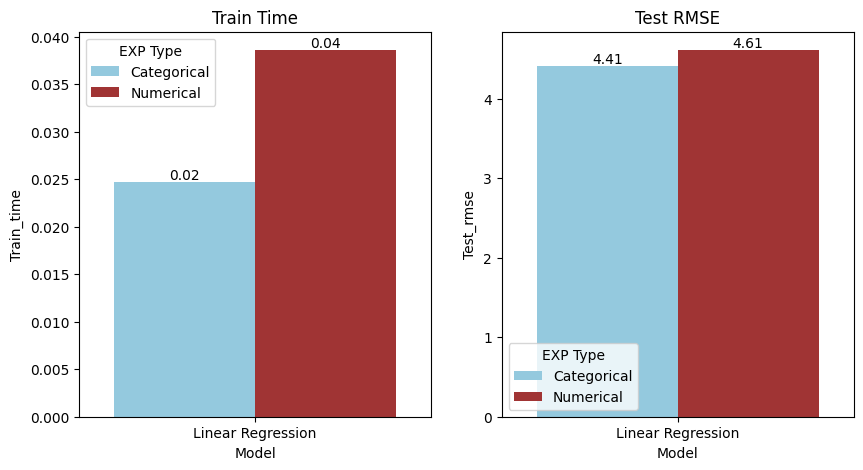

In [19]:
# Plotting Combined reusults to compare RMSE & Training Time for both Baselines.
fig, ax = plt.subplots(1, 2, figsize = (10,5))
colors = ['firebrick' if c > baseline_test_rmse else 'skyblue' for c in comparison_results['Test_rmse']]
sns.barplot(data = comparison_results, x = 'Model', y = 'Train_time', hue = 'EXP Type', ax = ax[0], palette = colors)
ax[0].set_title('Train Time')
for container in ax[0].containers:
  ax[0].bar_label(container, fmt = '%.2f')
sns.barplot(data = comparison_results, x = 'Model', y = 'Test_rmse', hue = 'EXP Type', ax = ax[1], palette = colors)
ax[1].set_title('Test RMSE')
for container in ax[1].containers:
  ax[1].bar_label(container, fmt = '%.2f')

In [20]:
# Assessing Drop in performance / Increase in Error between Models.
b_rmse = b_results['results']['Test_rmse'].mean()
b2_rmse = b2_results['results']['Test_rmse'].mean()
percent_drop = ((b_rmse - b2_rmse)/b_rmse ) *100
print(f'Performance drop of {percent_drop:.2f}%')

Performance drop of -4.57%


In [21]:
# Updating Baseline Metrics Tracking
baseline_train_time = b2_results['results']['Train_time'].mean()
baseline_test_rmse = b2_results['results']['Test_rmse'].mean()
baseline_test_mae = b2_results['results']['Test_mae'].mean()
baseline_test_r2 = b2_results['results']['Test_r2'].mean()

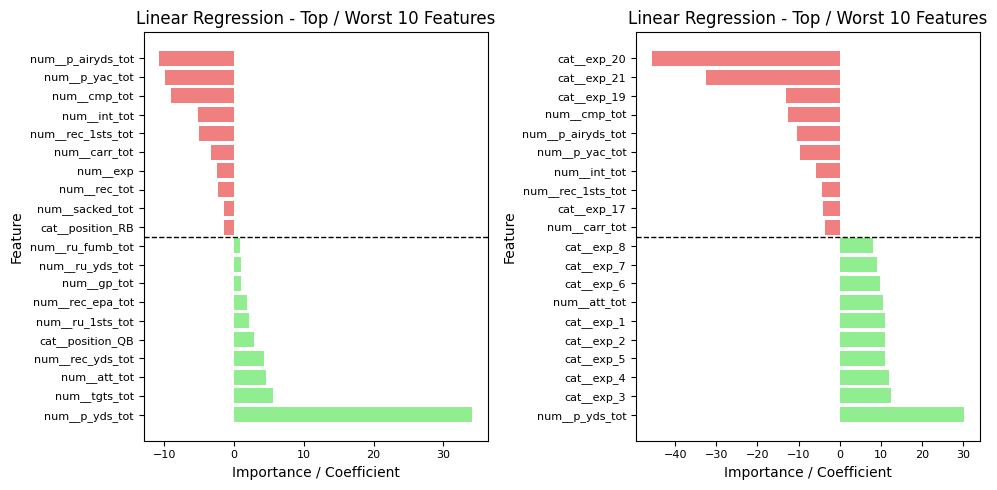

In [22]:
# Plotting of Top / Worst Features for Baseline Models.
fig, ax = plt.subplots(1,2, figsize = (10,5))
b2_all_stat = feature_extractor('Linear Regression', b2_results['models']['Linear Regression'])
plot_fts(b2_all_stat, 'Linear Regression', ax[0])
plot_fts(all_stat, 'Linear Regression', ax[1])
plt.tight_layout()
plt.show()

## Secondary Baseline Findings


---

After re-running the baseline with experience as a numerical feature, we noticed a slight decline in performance of about -4.5%. However, this change also resulted in improved learnings from the model overall. A wider array of features holding higher significance within the model was learned, which aligns much cleaner with the question we are seeking to answer.  



## Base Models Experimentation

---
After establishing a baseline Linear Regression Model for comparison, we will move forward with running multiple different base models with the same dataframe to compare model performance. From this we will select the top 3 models to use moving forward.

We will be utilizing the following models:


1.   Linear Regression (Baseline)
2.   Ridge Regression
3.   Lasso Regression
4.   ElasticNet
5.   RandomForest
6.   ExtraTrees
7.   GradientBoosting
8.   XGBoost
9.   CatBoost

In [23]:
# @title Base Models Dictionary
base_models = {
    'Linear Regression': LinearRegression(),
    'Ridge' : Ridge(random_state = 42),
    'Lasso' : Lasso(random_state = 42),
    'ElasticNet' : ElasticNet(random_state = 42),
    'RandomForest' :RandomForestRegressor(random_state = 42),
    'ExtraTrees' :ExtraTreesRegressor(random_state = 42),
    'GradientBoosting' : GradientBoostingRegressor(random_state = 42),
    'XGBoost' :XGBRegressor(random_state = 42, verbosity = 0),
    'CatBoost' : CatBoostRegressor(random_state = 42, verbose = 0)
}

In [24]:
# @title Plotting Functions for Metrics with Baseline Comparison & Features
# Bar plot function for visualization of Results Data
# Utilizing Baseline Metrics stored prior for color identification of better/worse peforming models

def plot_results(results_df):
  colors = ['firebrick' if c > baseline_test_rmse else 'skyblue' for c in results_df['Test_rmse']]
  fig , ax = plt.subplots(2, 2, figsize = (12,5))
  sns.barplot(data = results_df, y = 'Model', x = 'Train_time', ax = ax[0,0], palette = colors)
  ax[0,0].set_title('Train Time')
  for container in ax[0,0].containers:
    ax[0,0].bar_label(container, fmt = '%.2f')
  ax[0,0].axvline(x = baseline_train_time, color = 'black', linestyle = '--', linewidth = 1, label = 'Baseline')
  sns.barplot(data = results_df, y = 'Model', x = 'Test_rmse', ax = ax[0,1], palette = colors)
  ax[0,1].set_title('Test RMSE')
  for container in ax[0,1].containers:
    ax[0,1].bar_label(container, fmt = '%.2f')
  ax[0,1].axvline(x = baseline_test_rmse, color = 'black', linestyle = '--', linewidth = 1, label = 'Baseline')
  sns.barplot(data = results_df, y = 'Model', x = 'Test_mae', ax = ax[1,0], palette = colors)
  ax[1,0].set_title('Test MAE')
  for container in ax[1,0].containers:
    ax[1,0].bar_label(container, fmt = '%.2f')
  ax[1,0].axvline(x = baseline_test_mae, color = 'black', linestyle = '--', linewidth = 1, label = 'Baseline')
  sns.barplot(data = results_df, y = 'Model', x = 'Test_r2', ax = ax[1,1], palette = colors)
  ax[1,1].set_title('Test R2')
  for container in ax[1,1].containers:
    ax[1,1].bar_label(container, fmt = '%.2f')
  ax[1,1].axvline(x = baseline_test_r2, color = 'black', linestyle = '--', linewidth = 1, label = 'Baseline')
  plt.tight_layout()
  plt.show()

# Function for the plotting of the top 4 models from an experimental run.
def plot_features(experiments, top = True, bottom = True, n = 15):
  fig, ax = plt.subplots(2, 2, figsize = (15,8))
  ax = ax.flatten()
  for i, model in enumerate(experiments['results']['Model']):
    if i == 4:
      break
    fts = feature_extractor(model, experiments['models'][model])
    ax[i] =  plot_fts(fts, f'{model}', ax = ax[i], top = top , bottom = bottom, n = n)
  for j in range(i+1, len(ax)):
    fig.delaxes(ax[j])
  plt.tight_layout()
  plt.show()

In [25]:
# @title Base Model Experiments with Career Summation
# Features utilized will be b2_cat_fts/b2_num_fts matching baseline model.
base_features = b2_cat_fts + b2_num_fts

# Creation of Base Pipelines
base_pipes = {}
for model_name, model in base_models.items():
  base_pipes[model_name] = create_model_pipeline(model, b2_cat_fts, b2_num_fts)

# Run Models
base_sum_model_experiments = run_model_experiments(cntrct_sum, 'apy', base_features, base_pipes)

In [26]:
# Base Model Results incl. Baseline
base_sum_model_experiments['results']

,Model,Train_time,Train_rmse,Test_rmse,Train_mae,Test_mae,Train_r2,Test_r2
8,CatBoost,7.442866,1.287436,3.531362,0.834482,1.540781,0.952378,0.618771
4,RandomForest,13.344028,1.348544,3.593555,0.615118,1.585201,0.947750,0.605224
7,XGBoost,0.379454,0.496517,3.729701,0.351494,1.654051,0.992917,0.574745
5,ExtraTrees,2.647313,0.029924,3.843819,0.002831,1.616958,0.999974,0.548323
6,GradientBoosting,1.694104,2.391727,3.874963,1.343525,1.754188,0.835647,0.540974
0,Linear Regression,0.031619,4.360465,4.614963,2.505803,2.528768,0.453713,0.348914
1,Ridge,0.075835,4.370659,4.636230,2.505849,2.531944,0.451156,0.342900
3,ElasticNet,0.027963,5.019278,4.904738,2.630515,2.565220,0.276168,0.264584
2,Lasso,0.065538,5.211660,5.047891,2.807669,2.749831,0.219618,0.221028


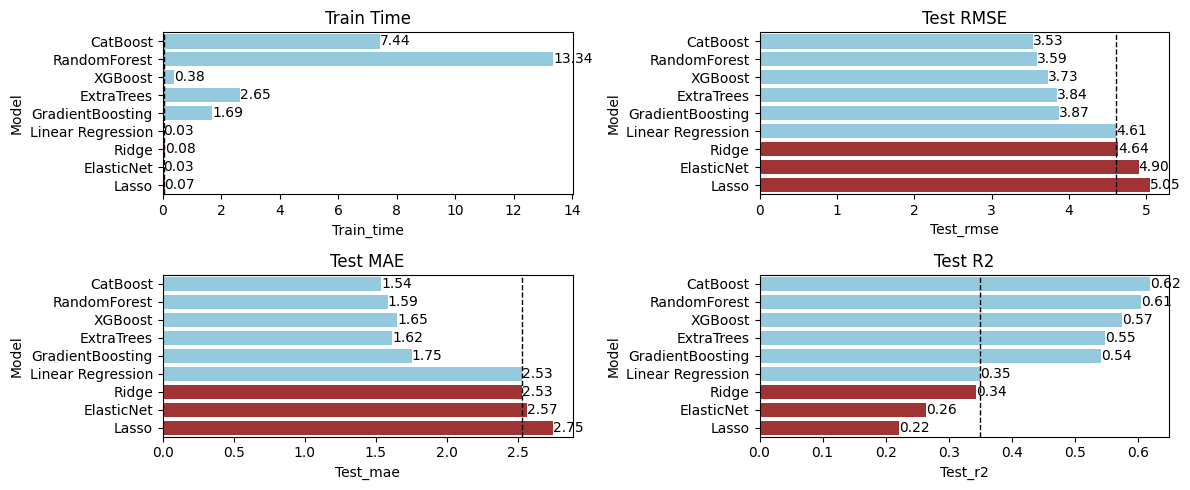

In [27]:
# @title Comparion of Metrics for Base Models
baseline_sum = base_sum_model_experiments['results']
plot_results(baseline_sum)

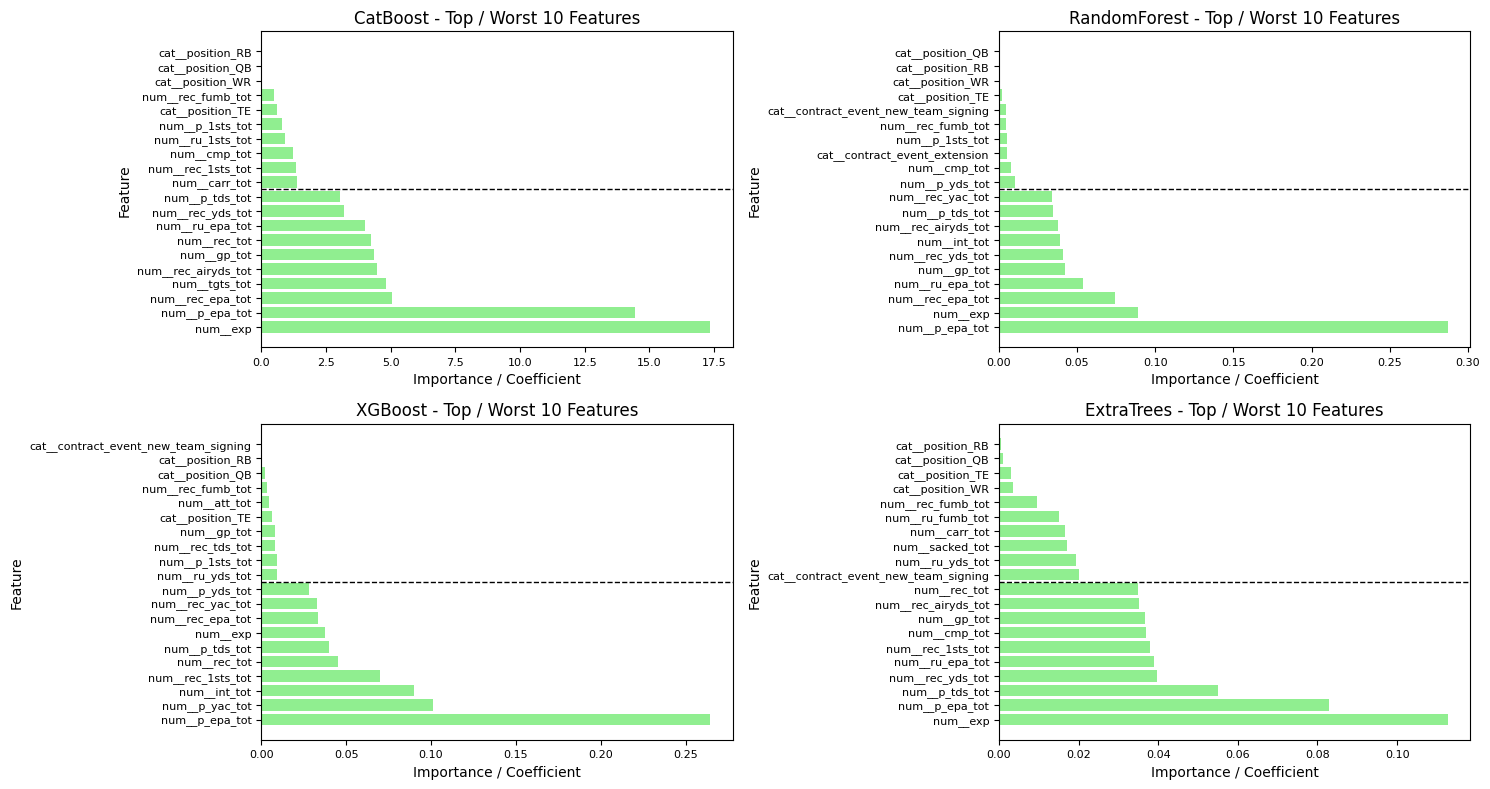

In [28]:
# @title Look over Feature Significance of Top Base Models
plot_features(base_sum_model_experiments, n = 10)

In [64]:
# Feature Summary of Top 15 Features in Baseline Models
print(f'Total Number of Features : {len(build_feature_summary(base_sum_model_experiments))}')
build_feature_summary(base_sum_model_experiments)[:15]

Total Number of Features : 33


,feature,CatBoost,RandomForest,XGBoost,ExtraTrees,GradientBoosting,Linear Regression,Ridge,ElasticNet,Lasso,Average Rank,Average Importance
0,num__exp,1.0,2.0,7.0,1.0,2.0,12.0,11.0,22.0,6.0,7.111111,0.339958
1,num__p_epa_tot,2.0,1.0,1.0,2.0,1.0,24.0,31.0,1.0,4.0,7.444444,0.639542
2,num__tgts_tot,4.0,13.0,19.0,13.0,12.0,5.0,3.0,4.0,3.0,8.444444,0.212935
3,num__rec_epa_tot,3.0,3.0,8.0,14.0,3.0,15.0,14.0,14.0,6.0,8.888889,0.192844
4,num__p_yac_tot,12.0,15.0,2.0,20.0,9.0,3.0,4.0,12.0,6.0,9.222222,0.216036
5,num__rec_yds_tot,9.0,6.0,20.0,4.0,14.0,9.0,8.0,13.0,2.0,9.444444,0.187189
6,num__int_tot,16.0,7.0,3.0,12.0,6.0,6.0,7.0,22.0,6.0,9.444444,0.168463
7,num__p_yds_tot,15.0,24.0,10.0,11.0,13.0,1.0,1.0,5.0,6.0,9.555556,0.342090
8,num__rec_airyds_tot,5.0,8.0,11.0,9.0,7.0,18.0,20.0,11.0,6.0,10.555556,0.156154
9,num__rec_tot,7.0,12.0,5.0,10.0,10.0,13.0,12.0,20.0,6.0,10.555556,0.143021


## Base Model Selections
We see that 5 out of the 8 base models ran performed better than our baseline Linear Regression Model. While we can stick with any combination of the top 5, we will move forward with the following:

1.   Linear Regression (Baseline)
2.   CatBoost
3.   XGBoost
4.   Random Forest

These models will grant us a good subset of models to compare.



In [30]:
# @title Dictionary of Test Models
test_models = {
  'Linear Regression': LinearRegression(),
  'CatBoost': CatBoostRegressor(random_state = 42, verbose = 0),
  'XGBoost' : XGBRegressor(random_state = 42, verbosity = 0),
  'RandomForest' : RandomForestRegressor(random_state = 42)
}

# Does a regluar season and play off stats split improve our ability to predict contract values?

## Regular and Post Season Split Models
---

Our baseline models captured the cumulative overall production of everyplayer, however this is without fully accounting for postseason success. Teams could potentially place addtional value on players who achieve certain success in regards to playoffs.  
To test this, I will seperate regular and post season production for each player and incorporate them into a new dataset for comparing to our original models.

### Feature Engineering - Data split based on Season type.
The next few code blocks is distinguishing players stats per game type, whether being regular season or post season.
Additionally, we will also alter other dataset including team stats and records for utilization on different model creations.

In [31]:
# @title ####Player Stats with Regular Season/Post Season Splits

# We want to seperate our regular season and post season stats.
reg = player_stats_filtered.loc[player_stats_filtered['season_type'] == 'REG'].copy()
post = player_stats_filtered.loc[player_stats_filtered['season_type'] == 'POST'].copy()

# Create groups for columns in the data, seperating identifying data from statistical data.
id_cols = ['player_id','player_name','player_display_name','team','position','season_type','season','week']

# Isolate remainder of columns for calculation of season totals per player.
stats_cols = [
    c for c in player_stats_filtered.columns if c not in id_cols
]

#Grouping for player stats
p_group = ['player_id','season','team']

# We want to add all stats per player per season for standard metrics.
# For the EPA metric, we will utilize the season averge per player.
reg_stats = reg.groupby(p_group)[stats_cols].sum().add_suffix('_reg')
reg_stats['gp_reg'] = reg.groupby(p_group)['season_type'].count()

# The same applies for the post season stats per player.
post_stats = post.groupby(p_group)[stats_cols].sum().add_suffix('_po')
post_stats['gp_po'] = post.groupby(p_group)['season_type'].count()

# Creation of a new aggregation columns for overall player games played per season
# this is to ultimately understand their avaialability and impact per season.
meta = player_stats_filtered.groupby(p_group).agg(
    player = ('player_display_name', 'first'),
    position = ('position', 'first'),
    gp_tot=('season_type', 'count'),
)

# Ultimately add the regular season and post season stats into one standard dataframe,
# joining them with the aggregations completed above.
season_stats = meta.join([reg_stats, post_stats]).reset_index()

# Fill the Null entries fromt the join with 0, given the metrics do not apply those players.
player_totals = season_stats.fillna(0)

# Re-organize the columns of the Dataframe.
player_cols = player_totals.columns.tolist()
# print(player_cols)
# new_cols = player_cols[2:4] + player_cols[0:2] + player_cols[4:]
# player_totals = player_totals[new_cols]

# Clean Up Dtypes
po_plyr_sts = player_totals.convert_dtypes()

In [32]:
# @title #### Team Season Stats Regular Season/ Post Seaon Splits

# Filter out to only include the columns of interest and abbreviate column names
season_stats = team_stats.rename(columns=new_stat_names)

# Seperate the identifier columns into a list
id_cols = ['season','week','season_type','team']

# Create a list of the remaining statistic columns
stat_cols = [ c for c in season_stats.columns if c not in id_cols]

# Create a Dataframe to seperate our regular season and post season stats.
team_reg = season_stats.loc[season_stats['season_type'] == 'REG'].copy()
team_post = season_stats.loc[season_stats['season_type'] == 'POST'].copy()
games = season_stats.copy()

# add all stats per team per season for standard metrics.
# For the EPA metric, we will utilize the season averge per team.
team_reg_stats = team_reg.groupby(['team','season'])[stat_cols].sum().add_suffix('_reg')

# The same applies for the post season stats.
team_post_stats = team_post.groupby(['team','season'])[stat_cols].sum().add_suffix('_po')

# Creation of a new aggregation columns for overall games played per season
games = games.groupby(['team','season']).agg(
    gp_tot=('season_type', 'count'),
)

# Ultimately add the regular season and post season stats into one standard dataframe,
# joining them with the aggregations completed above.
stats = games.join([team_reg_stats, team_post_stats]).reset_index()

# Fill the Null entries fromt the join with 0, given the metrics do not apply those teams.
po_tm_sts = stats.fillna(0).convert_dtypes()


In [33]:
# @title #### Regular Season/Post Season Record Splits
#  Goal from this Dataframe is to establish team and QB W/L records
#  Between regular season and post season.

# Seperate the data into regular season and post season games.
regs = combined.loc[combined['game_type'] == 'REG'].copy()
posts = combined.loc[~(combined['game_type'] == 'REG')].copy()
sb = combined.loc[combined['game_type'] == 'SB'].copy()

# Win Loss Aggregation Function for Team & QB Records
def win_loss_agg(reg,pos,sb,grouping):
  # Aggregation function for records data
  # For regular season games.
  r,p,s = reg.copy(),pos.copy(),sb.copy()
  r = regs.groupby(grouping).agg(
    w=('result', lambda x: (x == 'W').sum()),
    l=('result', lambda x: (x == 'L').sum()),
    gp=('result', 'count')
  ).add_suffix('_reg').reset_index()
  # For postseason games
  p = posts.groupby(grouping).agg(
    w=('result', lambda x: (x == 'W').sum()),
    l=('result', lambda x: (x == 'L').sum()),
    gp=('result', 'count'),
  ).add_suffix('_po').reset_index()
  # Superbowl
  s = sb.groupby(grouping).agg(
    w = ('result', lambda x: (x == 'W').sum()),
    l = ('result', lambda x: (x == 'L').sum()),
  ).add_suffix('_sb').reset_index()
  records = pd.merge(r,p, on=grouping, how='outer')
  records = pd.merge(records,s, on=grouping, how='outer')

  records = records.fillna(0)
  return records.convert_dtypes()

qbgroup = ['player','season','team']
team_group = ['team','season']

po_qb_rcds = win_loss_agg(regs,posts,sb,qbgroup)
po_tm_rcds = win_loss_agg(regs,posts,sb,team_group)

In [34]:
# @title Playoff/Regular Season Splits

# Aggregate Playoff Split data with contracts data
po_cntrct_sum = contract_stat_agg(po_plyr_sts)

# Seperation of Categorical and Numerical Features for preprocessor
po_cat_fts , po_num_fts = feature_splits(po_cntrct_sum)

# Creation of Test Pipelines
test_pipes = {}
for model_name, model in test_models.items():
  test_pipes[model_name] = create_model_pipeline(model, po_cat_fts, po_num_fts)

# Baseline Pipes for Test Set
base_test_pipes = {}
for model_name, model in test_models.items():
  base_test_pipes[model_name] = create_model_pipeline(model, b2_cat_fts, b2_num_fts)

# Run Models
test_sum_model_experiments = run_model_experiments(cntrct_sum, 'apy', base_features, base_test_pipes)
test_split_sum_model_experiments = run_model_experiments(po_cntrct_sum, 'apy', po_cat_fts + po_num_fts, test_pipes)

In [82]:
po_corr = po_cntrct_sum.corr(numeric_only= True)

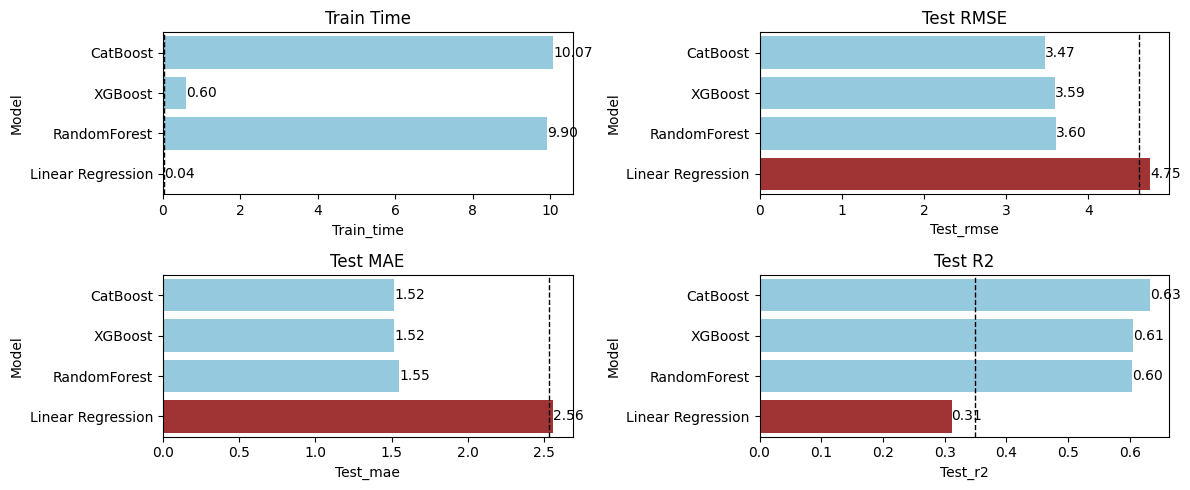

In [35]:
# @title Plots of Playoff Split Data Model Experiments Results
plot_results(test_split_sum_model_experiments['results'])

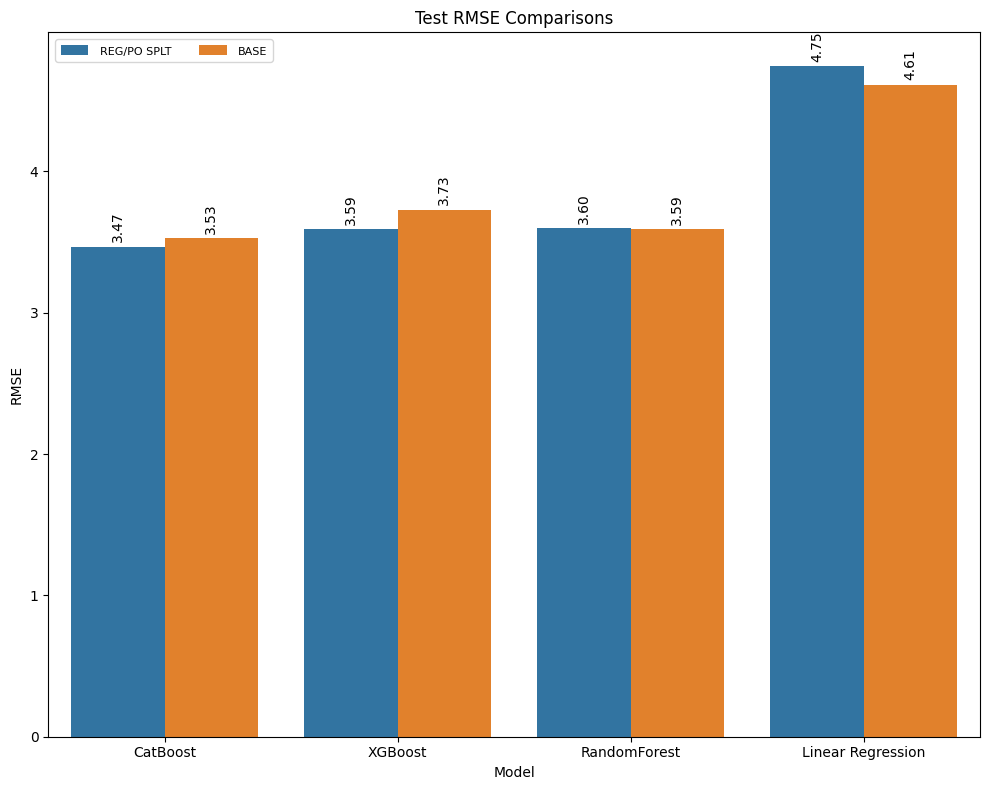

In [36]:
# @title Combined Results for Visualization on Base Test Models
test_splits = test_split_sum_model_experiments['results']
test_base = test_sum_model_experiments['results']
# Add new column for distinguishing purposes.
test_splits['Data'] = 'REG/PO SPLT'
test_base['Data'] = 'BASE'
compiled_results = pd.concat([test_splits, test_base])
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.barplot(data = compiled_results, x = 'Model', y = 'Test_rmse', hue = 'Data')
for container in ax.containers:
  ax.bar_label(container,padding = 3, rotation = 90, fmt = '%.2f')
ax.set_title('Test RMSE Comparisons')
ax.set_ylabel('RMSE')
ax.legend(loc='upper left', ncols=2)
plt.setp(ax.get_legend().get_texts(), fontsize='8')
plt.setp(ax.get_legend().get_title(), fontsize='8')
plt.tight_layout()
plt.show()

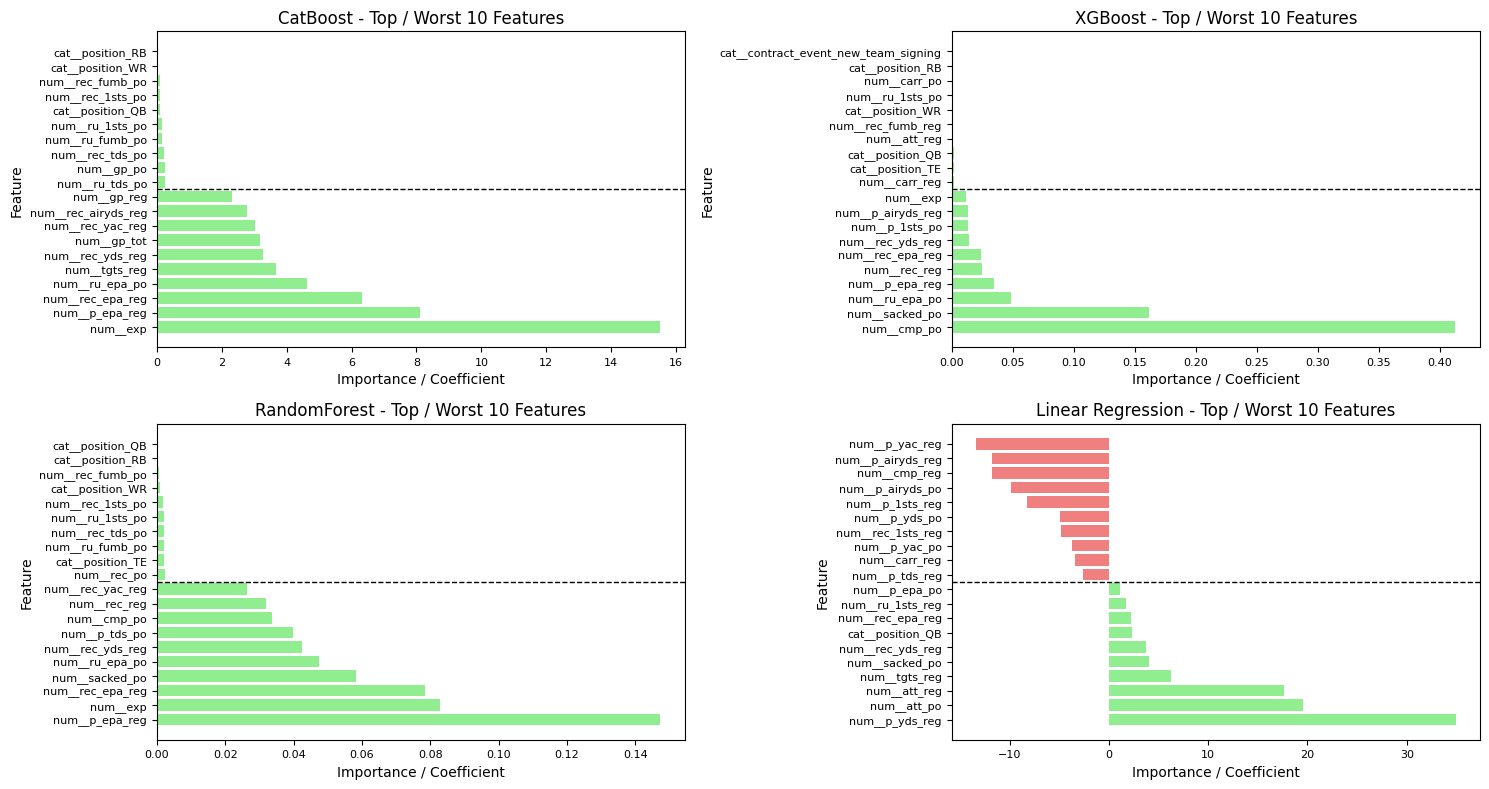

In [37]:
# Visualize Features from New Split Data
plot_features(test_split_sum_model_experiments, n = 10)

In [63]:
# Feature Summary on Top 20 Features of 60
print(f'Total Number of Features : {len(build_feature_summary(test_split_sum_model_experiments))}')
build_feature_summary(test_split_sum_model_experiments)[:20]

Total Number of Features : 60


,feature,CatBoost,XGBoost,RandomForest,Linear Regression,Average Rank,Average Importance
0,num__rec_yds_reg,6.0,7.0,6.0,13.0,8.00,0.160901
1,num__exp,1.0,10.0,2.0,21.0,8.50,0.414757
2,num__rec_epa_reg,3.0,6.0,3.0,23.0,8.75,0.265817
3,num__sacked_po,20.0,2.0,4.0,12.0,9.50,0.253457
4,num__tgts_reg,5.0,12.0,12.0,9.0,9.50,0.154160
5,num__rec_reg,11.0,5.0,9.0,20.0,11.25,0.122592
6,num__cmp_po,13.0,1.0,8.0,26.0,12.00,0.350046
7,num__ru_epa_po,4.0,3.0,5.0,37.0,12.25,0.190614
8,num__p_tds_po,14.0,13.0,7.0,17.0,12.75,0.125066
9,num__p_epa_reg,2.0,4.0,1.0,46.0,13.25,0.405308


## Split Data Model Results

---
After seperating player stats between regular season and post season, our selected test models were trained on the new data set. These results, compared to our baseline metrics, showed a subtle decrease in error from each model with the exception of the Linear Regression Baseline Model where the error increased. While it did get worse, the increase in error for that model is modest overall.
The data itself is not new information, it is simply formatted differently for the model to distinguish significance.

Additionally, while looking over the best and worst features in each model, we notice some the playoff features implemented did come forth as some features with high importance. This holds promise towards discovering what data is vital for contract estimations, and will prove to be a good starting point for finding the best set of features for our final model.

# Does player efficiency a better way to measure contract values compared to total stats?
## Player Efficiency Metrics Models

---

After utilization of the splits between playoff and regular season data, we shift our focus towards the implemantation of efficiency metrics for each player. While volume statistics are significant, they may not accurately reflect play quality. Different players can accumulate similar production despite having different levels of efficiency. This final experiment will help determine whether teams appear to reward efficiency over cumulation production.

We will also test features that provide a players perccentage contribution to overall team stats.

In [39]:
# @title Player Efficiency Formulas
# Create formulas for efficiency metrics from stats
# Established different metrics given overall stats provided
# Also estbalished player percentage of contribution for team stats.
def safe_div(num,den):
  return np.where(den == 0, 0, num/den)

periods = ['tot','reg','po']
scopes = ['plyr','tm']

stat_groups = {
    'passing': [
        'att',
        'cmp',
        'p_yds',
        'p_tds',
        'int',
        'sacked'
        'p_airyds',
        'p_yac',
        'p_1sts'
    ],
    'rushing': [
        'carr',
        'ru_yds',
        'ru_tds',
        'ru_fumb',
        'ru_1sts'
    ],
    'receiving': [
        'rec',
        'tgts',
        'rec_yds',
        'rec_tds',
        'rec_fumb',
        'rec_airyds',
        'rec_yac',
        'rec_1sts'
    ],
    'epas' : [
        'p_epa',
        'ru_epa',
        'rec_epa'
    ],
    'p_eff' :[
        'cmp_pct',
        'yds_p_cmp',
        'yds_p_att',
        'tds_p_cmp',
        'td_p_att',
        'airyd_p_cmp',
        'airyd_p_att',
        'int_p_cmp',
        'int_p_att',
        'yac_p_cmp',
        'yac_p_att',
        '1sts_p_cmp',
        '1sts_p_att',
        'td_int_ratio',
        'p_ypg',
        'att_pg',
        'cmp_pg',
        'p_td_pg:',
        'p_airyd_pg',
        'int_pg',
        'p_yac_pg',
        'p_1sts_pg',
        'sack_p_g'
    ],
    'ru_eff' : [
        'ru_yds_p_carr',
        'ru_tds_p_carr',
        'fumb_p_carr',
        'ru_1sts_p_carr',
        'ru_ypg',
        'carr_pg',
        'ru_tds_pg',
        'ru_fumb_pg',
        'ru_1sts_pg'
    ],
    'rec_eff' : [
        'yds_p_tgts',
        'yds_p_rec',
        'tds_p_tgts',
        'tds_p_rec',
        'fumb_p_tgts',
        'fumb_p_rec',
        'airyds_p_tgts',
        'airyds_p_rec',
        '1sts_p_tgts',
        '1sts_p_rec',
        'yac_p_tgts',
        'yac_p_rec',
        'rec_pct',
        'rec_ypg',
        'rec_tds_pg',
        'rec_pg',
        'tgts_pg',
        'rec_airyds_pg',
        'rec_yac_pg',
        'rec_1sts_pg'
    ]
}

# Different subsets of stats for percent calculations.
GENERAL_STATS = ['passing','rushing','receiving','epas']
EFF_STATS = ['p_eff','ru_eff','rec_eff']
ALL_STATS = GENERAL_STATS + EFF_STATS

# All efficiency metrics possible.
FEATURE_RECIPES = {
        'cmp_pct': ('cmp', 'att'),
        'yds_p_cmp': ('p_yds', 'cmp'),
        'yds_p_att': ('p_yds', 'att'),
        'tds_p_cmp' : ('p_tds', 'cmp'),
        'td_p_att': ('p_tds', 'att'),
        'airyd_p_cmp': ('p_airyds', 'cmp'),
        'airyd_p_att': ('p_airyds', 'att'),
        'int_p_cmp': ('int', 'cmp'),
        'int_p_att': ('int', 'att'),
        'yac_p_cmp': ('p_yac', 'cmp'),
        'yac_p_att': ('p_yac', 'att'),
        '1sts_p_cmp': ('p_1sts', 'cmp'),
        '1sts_p_att': ('p_1sts', 'att'),
        'td_int_ratio': ('p_tds', 'int'),
        'ru_yds_p_carr': ('ru_yds', 'carr'),
        'ru_tds_p_carr': ('ru_tds', 'carr'),
        'fumb_p_carr': ('ru_fumb', 'carr'),
        'ru_1sts_p_carr': ('ru_1sts', 'carr'),
        'yds_p_tgts': ('rec_yds', 'tgts'),
        'yds_p_rec': ('rec_yds', 'rec'),
        'tds_p_tgts': ('rec_tds', 'tgts'),
        'tds_p_rec': ('rec_tds', 'rec'),
        'fumb_p_tgts': ('rec_fumb', 'tgts'),
        'fumb_p_rec': ('rec_fumb', 'rec'),
        'airyds_p_tgts': ('rec_airyds', 'tgts'),
        'airyds_p_rec': ('rec_airyds', 'rec'),
        '1sts_p_tgts': ('rec_1sts', 'tgts'),
        '1sts_p_rec': ('rec_1sts', 'rec'),
        'yac_p_tgts': ('rec_yac', 'tgts'),
        'yac_p_rec': ('rec_yac', 'rec'),
        'rec_pct': ('rec', 'tgts'),
        'p_ypg': ('p_yds', 'gp'),
        'att_pg': ('att', 'gp'),
        'cmp_pg': ('cmp', 'gp'),
        'p_td_pg': ('p_tds', 'gp'),
        'p_airyd_pg': ('p_airyds', 'gp'),
        'int_pg': ('int', 'gp'),
        'p_yac_pg': ('p_yac', 'gp'),
        'p_1sts_pg': ('p_1sts', 'gp'),
        'sack_p_g': ('sacked', 'gp'),
        'ru_ypg': ('ru_yds', 'gp'),
        'carr_pg': ('carr', 'gp'),
        'ru_tds_pg': ('ru_tds', 'gp'),
        'ru_fumb_pg': ('ru_fumb', 'gp'),
        'ru_1sts_pg': ('ru_1sts', 'gp'),
        'rec_ypg': ('rec_yds', 'gp'),
        'rec_tds_pg': ('rec_tds', 'gp'),
        'rec_pg': ('rec', 'gp'),
        'tgts_pg': ('tgts', 'gp'),
        'rec_airyds_pg': ('rec_airyds', 'gp'),
        'rec_yac_pg': ('rec_yac', 'gp'),
        'rec_1sts_pg': ('rec_1sts', 'gp'),
    }

# Function for Creation of New Column Names in Data Frame.
def build_col_name(stat,period,scope=None):
    if scope is None:
        return f'{stat}_{period}'
    return f'{stat}_{period}_{scope}'

# Function for generation of ratio features of a given DF.
# Made to work with any combination of player and team stats.
def gen_ratio_fts(df,periods,scopes = None):
  temp = df.copy()
  for feature_name,(num_stat,den_stat) in FEATURE_RECIPES.items():
    for period in periods:
      if scopes is None:
        num_col = build_col_name(num_stat,period)
        den_col = build_col_name(den_stat,period)
        new_col = f'{feature_name}_{period}'

        if (
            num_col in temp.columns and
            den_col in temp.columns
        ):
          temp[new_col] = safe_div(
              temp[num_col],
              temp[den_col]
          )
      else:
        for scope in scopes:
          num_col = build_col_name(num_stat,period,scope)
          den_col = build_col_name(den_stat,period,scope)
          new_col = f'{feature_name}_{period}_{scope}'
          if (
              num_col in temp.columns and
              den_col in temp.columns
          ):
            temp[new_col] = safe_div(
                temp[num_col],
                temp[den_col]
            )
  return temp

# Generation of Player Percentage contribtion to overall team stats.
def gen_pct_fts(df,stats,periods):
  temp = df.copy()
  for stat in stats:
    for period in periods:
      plyr_col = f"{stat}_{period}_plyr"
      tm_col = f"{stat}_{period}_tm"
      new_col = f"{stat}_pct_{period}"
      if (plyr_col in temp.columns and
          tm_col in temp.columns):
        temp[new_col] = safe_div(temp[plyr_col],temp[tm_col])
  return temp

# For Cleaning of DF with Team data to player only for model trainings.
def clean_stats(df):
  temp = df.copy()
  for col in df.columns:
    if col.endswith('_tm'):
      temp.drop(columns=col,inplace=True)
    if col.endswith('_plyr'):
      temp.rename(columns={col:col.replace('_plyr','')},inplace=True)
  return temp

# Support Function for percentage feature function.
# Takes a subset of features to create a final list.
def stat_list_generator(subset):
  x = []
  for stat in subset:
    x.extend(stat_groups[stat])
  return x

In [40]:
# Generate Ratio Features for Playoff Split Data
contract_plyr_eff_split_totals = gen_ratio_fts(
    df=po_cntrct_sum,
    periods=periods
)

In [41]:
contract_plyr_eff_split_totals.head()

,position,apy,exp,contract_event,gp_tot,cmp_reg,att_reg,p_yds_reg,p_tds_reg,int_reg,sacked_reg,p_airyds_reg,p_yac_reg,p_1sts_reg,p_epa_reg,carr_reg,ru_yds_reg,ru_tds_reg,ru_fumb_reg,ru_1sts_reg,ru_epa_reg,rec_reg,tgts_reg,rec_yds_reg,rec_tds_reg,rec_fumb_reg,rec_airyds_reg,rec_yac_reg,rec_1sts_reg,rec_epa_reg,gp_reg,cmp_po,att_po,p_yds_po,p_tds_po,int_po,sacked_po,p_airyds_po,p_yac_po,p_1sts_po,p_epa_po,carr_po,ru_yds_po,ru_tds_po,ru_fumb_po,ru_1sts_po,ru_epa_po,rec_po,tgts_po,rec_yds_po,rec_tds_po,rec_fumb_po,rec_airyds_po,rec_yac_po,rec_1sts_po,rec_epa_po,gp_po,cmp_pct_reg,cmp_pct_po,yds_p_cmp_reg,yds_p_cmp_po,yds_p_att_reg,yds_p_att_po,tds_p_cmp_reg,tds_p_cmp_po,td_p_att_reg,td_p_att_po,airyd_p_cmp_reg,airyd_p_cmp_po,airyd_p_att_reg,airyd_p_att_po,int_p_cmp_reg,int_p_cmp_po,int_p_att_reg,int_p_att_po,yac_p_cmp_reg,yac_p_cmp_po,yac_p_att_reg,yac_p_att_po,1sts_p_cmp_reg,1sts_p_cmp_po,1sts_p_att_reg,1sts_p_att_po,td_int_ratio_reg,td_int_ratio_po,ru_yds_p_carr_reg,ru_yds_p_carr_po,ru_tds_p_carr_reg,ru_tds_p_carr_po,fumb_p_carr_reg,fumb_p_carr_po,ru_1sts_p_carr_reg,ru_1sts_p_carr_po,yds_p_tgts_reg,yds_p_tgts_po,yds_p_rec_reg,yds_p_rec_po,tds_p_tgts_reg,tds_p_tgts_po,tds_p_rec_reg,tds_p_rec_po,fumb_p_tgts_reg,fumb_p_tgts_po,fumb_p_rec_reg,fumb_p_rec_po,airyds_p_tgts_reg,airyds_p_tgts_po,airyds_p_rec_reg,airyds_p_rec_po,1sts_p_tgts_reg,1sts_p_tgts_po,1sts_p_rec_reg,1sts_p_rec_po,yac_p_tgts_reg,yac_p_tgts_po,yac_p_rec_reg,yac_p_rec_po,rec_pct_reg,rec_pct_po,p_ypg_reg,p_ypg_po,att_pg_reg,att_pg_po,cmp_pg_reg,cmp_pg_po,p_td_pg_reg,p_td_pg_po,p_airyd_pg_reg,p_airyd_pg_po,int_pg_reg,int_pg_po,p_yac_pg_reg,p_yac_pg_po,p_1sts_pg_reg,p_1sts_pg_po,sack_p_g_reg,sack_p_g_po,ru_ypg_reg,ru_ypg_po,carr_pg_reg,carr_pg_po,ru_tds_pg_reg,ru_tds_pg_po,ru_fumb_pg_reg,ru_fumb_pg_po,ru_1sts_pg_reg,ru_1sts_pg_po,rec_ypg_reg,rec_ypg_po,rec_tds_pg_reg,rec_tds_pg_po,rec_pg_reg,rec_pg_po,tgts_pg_reg,tgts_pg_po,rec_airyds_pg_reg,rec_airyds_pg_po,rec_yac_pg_reg,rec_yac_pg_po,rec_1sts_pg_reg,rec_1sts_pg_po
0,WR,25.000,3,new_team_signing,48,0,2,0,0,0,0,42,0,0,-1.251458,5,70,1,0,3,3.939331,185,295,2995,24,3,3475,1132,139,148.957991,43,0,0,0,0,0,0,0,0,0,0.0,1,9,0,0,0,0.876713,16,29,289,2,0,401,74,12,13.778632,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.000000,9.0,0.2,0.0,0.000000,0.0,0.600000,0.0,10.152542,9.965517,16.189189,18.062500,0.081356,0.068966,0.129730,0.125000,0.010169,0.0,0.016216,0.0,11.779661,13.827586,18.783784,25.062500,0.471186,0.413793,0.751351,0.750000,3.837288,2.551724,6.118919,4.625000,0.627119,0.551724,0.0,0.0,0.046512,0.0,0.0,0.0,0.0,0.0,0.976744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.627907,1.800,0.116279,0.200,0.023256,0.0,0.000000,0.0,0.069767,0.0,69.651163,57.800000,0.558140,0.400,4.302326,3.200000,6.860465,5.800000,80.813953,80.200,26.325581,14.800000,3.232558,2.40
1,WR,32.000,5,new_team_signing,85,0,2,0,0,0,0,42,0,0,-1.251458,5,70,1,0,3,3.939331,379,598,5947,42,7,7078,2157,268,270.700855,77,0,0,0,0,0,0,0,0,0,0.0,1,9,0,0,0,0.876713,29,51,435,3,0,691,125,20,18.977289,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.000000,9.0,0.2,0.0,0.000000,0.0,0.600000,0.0,9.944816,8.529412,15.691293,15.000000,0.070234,0.058824,0.110818,0.103448,0.011706,0.0,0.018470,0.0,11.836120,13.549020,18.675462,23.827586,0.448161,0.392157,0.707124,0.689655,3.607023,2.450980,5.691293,4.310345,0.633779,0.568627,0.0,0.0,0.025974,0.0,0.0,0.0,0.0,0.0,0.545455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.909091,1.125,0.064935,0.125,0.012987,0.0,0.000000,0.0,0.038961,0.0,77.233766,54.375000,0.545455,0.375,4.922078,3.625000,7.766234,6.375000,91.922078,86.375,28.012987,15.625000,3.480519,2.50
2,TE,0.720,4,new_team_signing,21,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0.0,40,65,452,3,2,541,151,21,-1.56869,21,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [42]:
# @title Efficiencty Metrics Test Models
# Feature splits
eff_cat_fts , eff_num_fts = feature_splits(contract_plyr_eff_split_totals)

# Test Pipes
eff_test_pipes = {}
for model_name, model in test_models.items():
  eff_test_pipes[model_name] = create_model_pipeline(model, eff_cat_fts, eff_num_fts)

# Model Trainings
eff_test_sum_model_experiments = run_model_experiments(contract_plyr_eff_split_totals, 'apy', eff_cat_fts + eff_num_fts, eff_test_pipes)

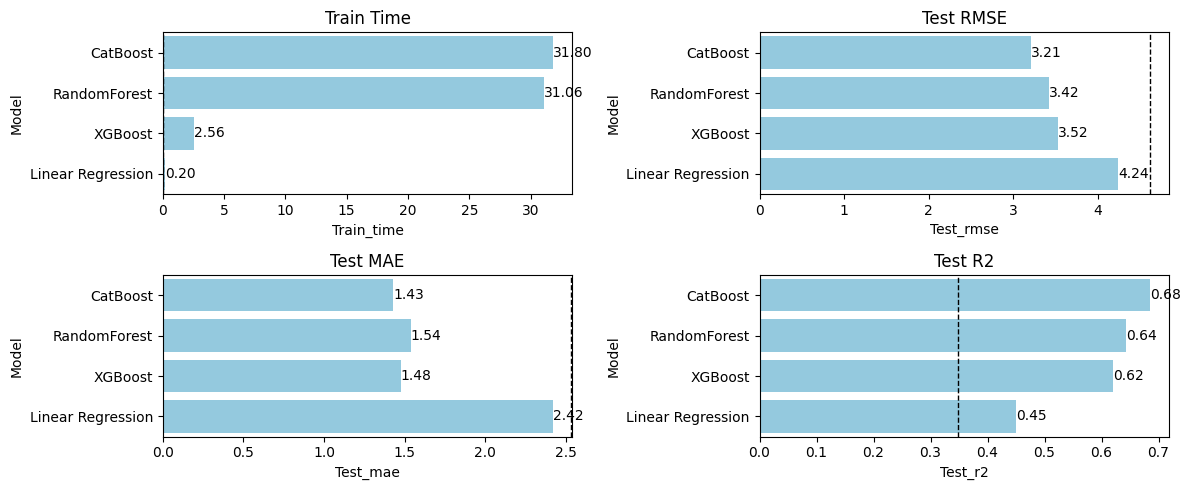

In [43]:
# Plotting of Metrics for Results with Efficiency Data.
plot_results(eff_test_sum_model_experiments['results'])

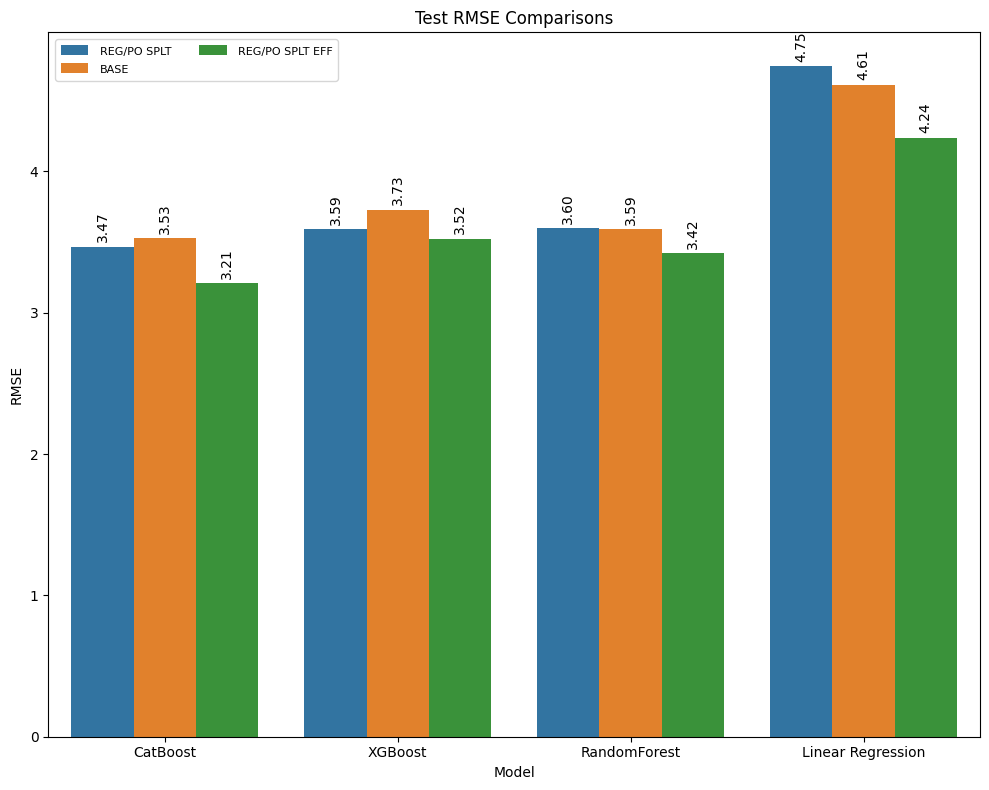

In [44]:
# Compiling results for all models up to this point for comparing different data sets and results.
eff_results = eff_test_sum_model_experiments['results']
eff_results['Data'] = 'REG/PO SPLT EFF'
compiled_results = pd.concat([compiled_results, eff_results])
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.barplot(data = compiled_results, x = 'Model', y = 'Test_rmse', hue = 'Data')
for container in ax.containers:
  ax.bar_label(container,padding = 3, rotation = 90, fmt = '%.2f')
ax.set_title('Test RMSE Comparisons')
ax.set_ylabel('RMSE')
ax.legend(loc='upper left', ncols=2)
plt.setp(ax.get_legend().get_texts(), fontsize='8')
plt.setp(ax.get_legend().get_title(), fontsize='8')
plt.tight_layout()
plt.show()

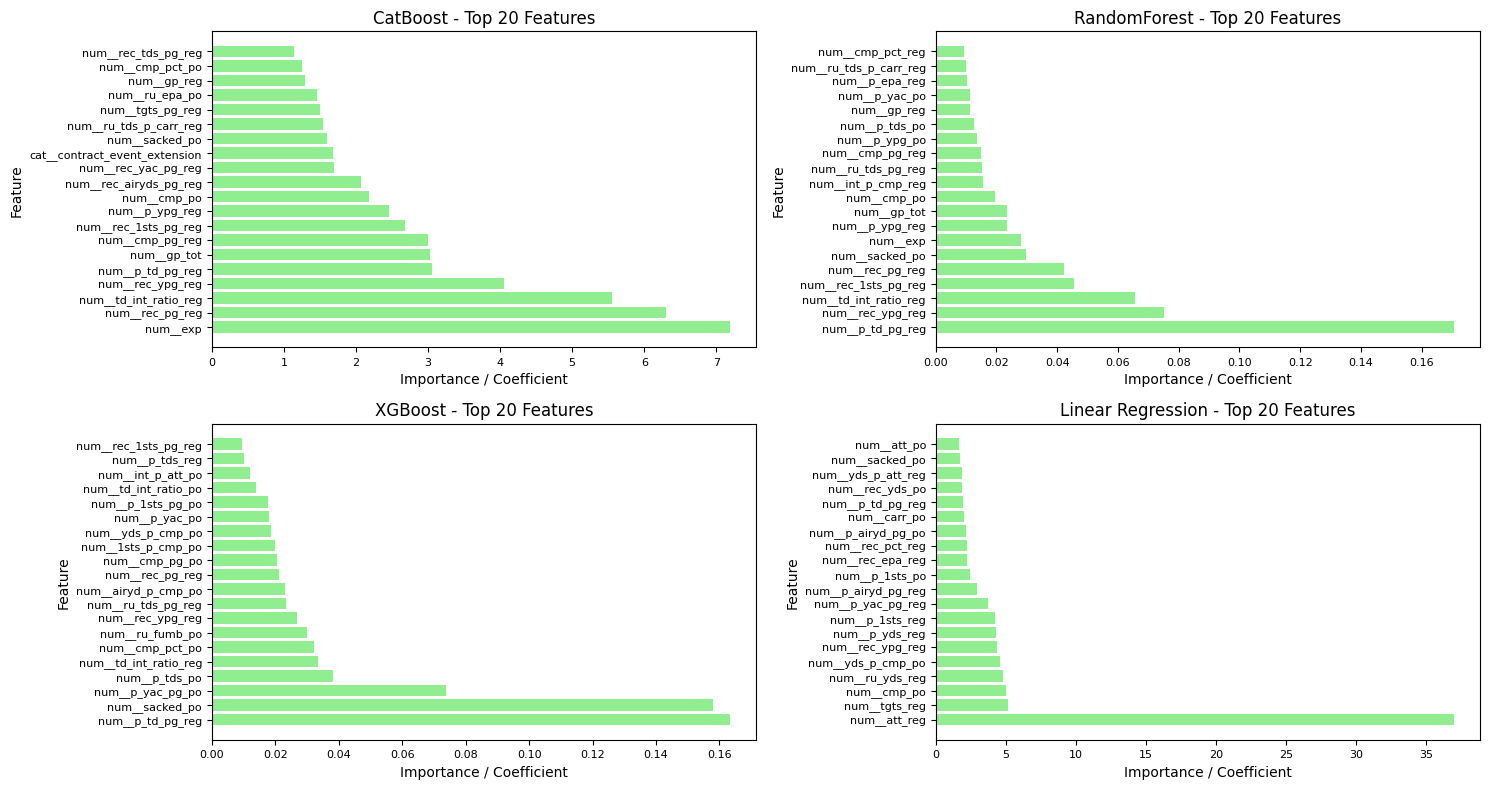

In [45]:
plot_features(eff_test_sum_model_experiments,bottom = False, n = 20)

In [46]:
# Feature Summary of Top 30 out of 164 Features
print(f'Total Number of Features : {len(build_feature_summary(eff_test_sum_model_experiments))}')
build_feature_summary(eff_test_sum_model_experiments)[:30]

Total Number of Features : 164


,feature,CatBoost,RandomForest,XGBoost,Linear Regression,Average Rank,Average Importance
0,num__rec_ypg_reg,4.0,2.0,8.0,13.0,6.75,0.321431
1,num__p_td_pg_reg,5.0,1.0,1.0,32.0,9.75,0.619466
2,num__sacked_po,14.0,6.0,2.0,39.0,15.25,0.352783
3,num__p_tds_po,37.0,15.0,4.0,17.0,18.25,0.127107
4,num__rec_pg_reg,2.0,5.0,11.0,64.0,20.50,0.319268
5,num__cmp_pg_reg,7.0,13.0,25.0,43.0,22.00,0.144836
6,num__td_int_ratio_reg,3.0,3.0,5.0,89.0,25.00,0.343951
7,num__tgts_reg,24.0,44.0,34.0,8.0,27.50,0.082566
8,num__p_ypg_reg,9.0,8.0,36.0,59.0,28.00,0.132576
9,num__exp,1.0,7.0,63.0,44.0,28.75,0.303899


## Efficiency Metrics Model Findings

---
Following our introduction of Efficiency metrics to our playoff split data, we see an improvement in the baseline models all around. While the improvement is nothing major, it illustrates to us that efficiency metrics are significant enough to utilize and analyze for our final dataset.

We are also starting to see an increase in training times, which is expected overall with the increase in features. We will utilize features rankings to finalize a feature set for our optimization steps.


## Percentage of Team Stat Metrics Model

---
Apart from individual player efficiency, does the amount a player contributed to the overall team stats hold any impact on the contract valuation?

In [47]:
# Combine Player and Team Split Data to one.
plyr_tm_stats = pd.merge(po_plyr_sts,po_tm_sts, on=['team','season'], how='left', suffixes=('_plyr','_tm'))
# Aggregate Stats after merging with contract data
contract_plyr_tm_sts = contract_stat_agg(plyr_tm_stats)

In [48]:
# Generate Percentage of Contribution for general stats of a player.
contract_plyr_tm_pcts = gen_pct_fts(
    df = contract_plyr_tm_sts,
    stats = stat_list_generator(GENERAL_STATS),
    periods = periods
)

# Clean dataframe to remove any team stats.
contract_po_plyr_pcts = clean_stats(contract_plyr_tm_pcts)

In [49]:
# Creation of Model Pipelines and Running Model.
pct_cat_fts , pct_num_fts = feature_splits(contract_po_plyr_pcts)

# Pipelines
pct_test_pipes = {}
for model_name, model in test_models.items():
  pct_test_pipes[model_name] = create_model_pipeline(model, pct_cat_fts, pct_num_fts)

pct_test_sum_model_experiments = run_model_experiments(contract_po_plyr_pcts, 'apy', pct_cat_fts + pct_num_fts, pct_test_pipes)

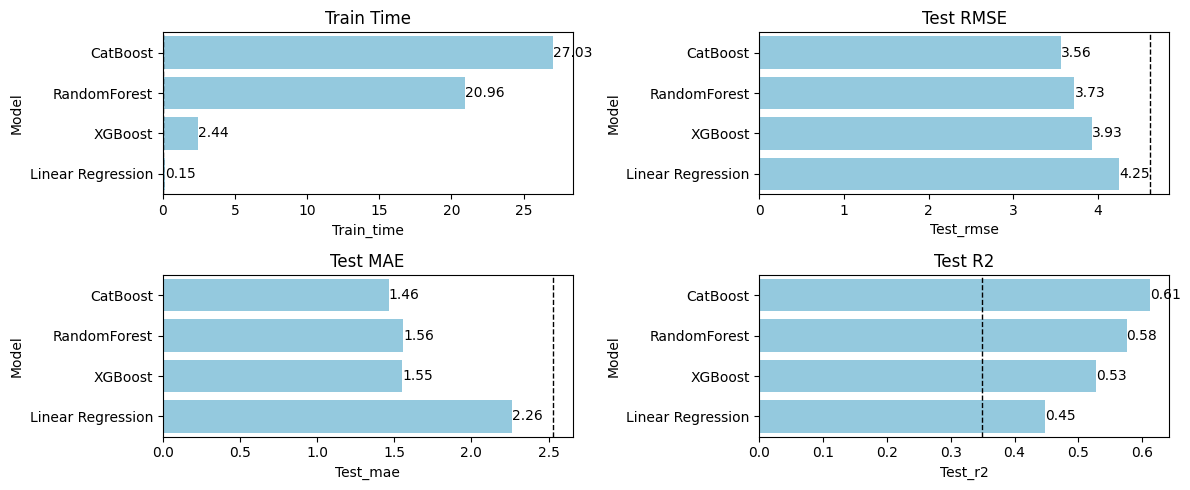

In [50]:
# Plotting of Metrics for Percent Feature Adds.
plot_results(pct_test_sum_model_experiments['results'])

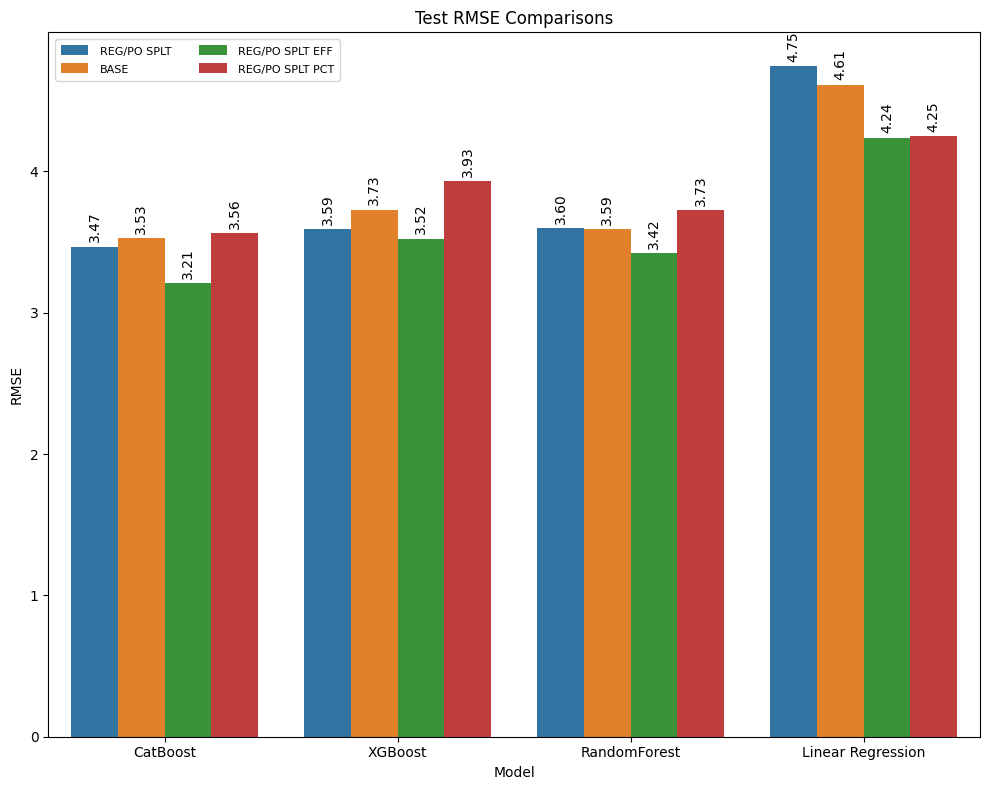

In [51]:
# Adding results to compiled results and plotting for comparison.
pct_results = pct_test_sum_model_experiments['results']
pct_results['Data'] = 'REG/PO SPLT PCT'
compiled_results = pd.concat([compiled_results, pct_results])
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.barplot(data = compiled_results, x = 'Model', y = 'Test_rmse', hue = 'Data')
for container in ax.containers:
  ax.bar_label(container,padding = 3, rotation = 90, fmt = '%.2f')
ax.set_title('Test RMSE Comparisons')
ax.set_ylabel('RMSE')
ax.legend(loc='upper left', ncols=2)
plt.setp(ax.get_legend().get_texts(), fontsize='8')
plt.setp(ax.get_legend().get_title(), fontsize='8')
plt.tight_layout()
plt.show()

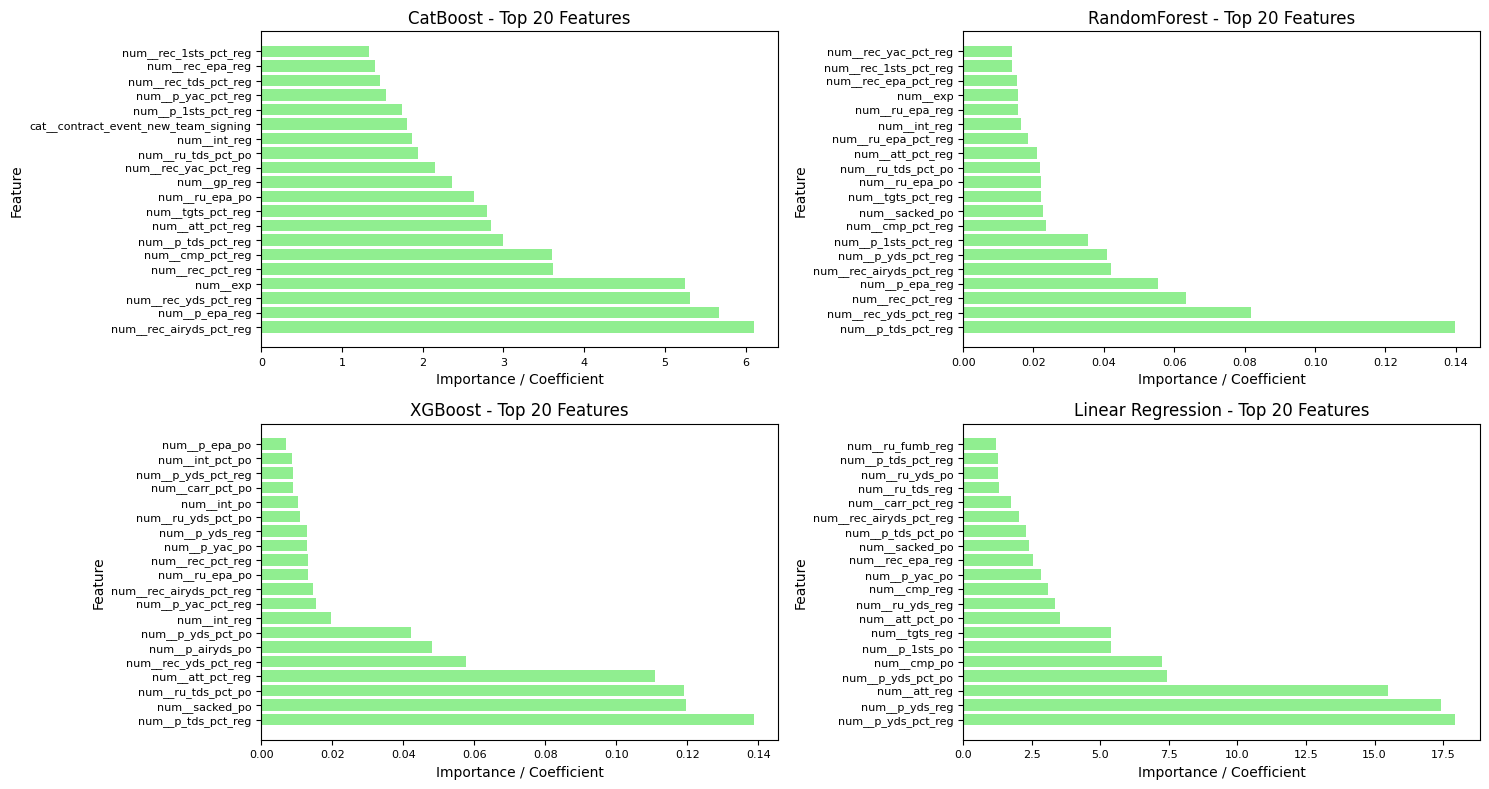

In [52]:
# Look at the Top 20 Features for each model.
plot_features(pct_test_sum_model_experiments, bottom = False, n = 20)

In [53]:
# Features Summary for top 20 out of 106 Features
print(f'Total Number of Features : {len(build_feature_summary(pct_test_sum_model_experiments))}')
build_feature_summary(pct_test_sum_model_experiments)[:20]

Total Number of Features : 106


,feature,CatBoost,RandomForest,XGBoost,Linear Regression,Average Rank,Average Importance
0,num__p_tds_pct_reg,7.0,1.0,1.0,37.0,11.50,0.640172
1,num__att_pct_reg,8.0,13.0,4.0,22.0,11.75,0.394146
2,num__rec_airyds_pct_reg,1.0,5.0,10.0,31.0,11.75,0.379840
3,num__p_1sts_pct_reg,16.0,7.0,21.0,5.0,12.25,0.310813
4,num__p_yds_pct_reg,25.0,6.0,18.0,1.0,12.50,0.385292
5,num__int_reg,14.0,15.0,8.0,20.0,14.25,0.187958
6,num__rec_yds_pct_reg,3.0,2.0,5.0,50.0,15.00,0.478970
7,num__sacked_po,28.0,9.0,2.0,28.0,16.75,0.333676
8,num__rec_pct_reg,5.0,3.0,12.0,60.0,20.00,0.292003
9,num__cmp_pct_reg,6.0,8.0,27.0,44.0,21.25,0.214186


## Percentage of Team Stat Metrics Results

---
Between the efficiency metrics and percentage of team stat responsibility metrics, efficiency was more beneficial for model improvements, only in our Baseline Linear Regression Model did the model perform slightly better.
For our final implementation, we will utilize both efficiency and percentage metrics to add all potential features into each model for our selection of top features to use moving forward.


## Cumulative Split with Efficiency and Percentage Models

---
Our final stint will be to utilize all potential data for training on the model. While this will ultimately increase training time, it will allow us to learn which features will be most impactful overall for our goal, and allow us to select the best features in order to move forward to model optimization.


In [55]:
# Generating Efficiency Metrics on DF with Player Percentages of Team Stats.
contract_pct_eff_split_totals = gen_ratio_fts(
    df=contract_po_plyr_pcts,
    periods=periods
)

In [57]:
# Creation of Feature Splits for Pipelines
pct_eff_cat_fts , pct_eff_num_fts = feature_splits(contract_pct_eff_split_totals)

# Model Pipelines
pct_eff_test_pipes = {}
for model_name, model in test_models.items():
  pct_eff_test_pipes[model_name] = create_model_pipeline(model, pct_eff_cat_fts, pct_eff_num_fts)

# Running Model Trainings
pct_eff_test_sum_model_experiments = run_model_experiments(contract_pct_eff_split_totals, 'apy', pct_eff_cat_fts + pct_eff_num_fts, pct_eff_test_pipes)


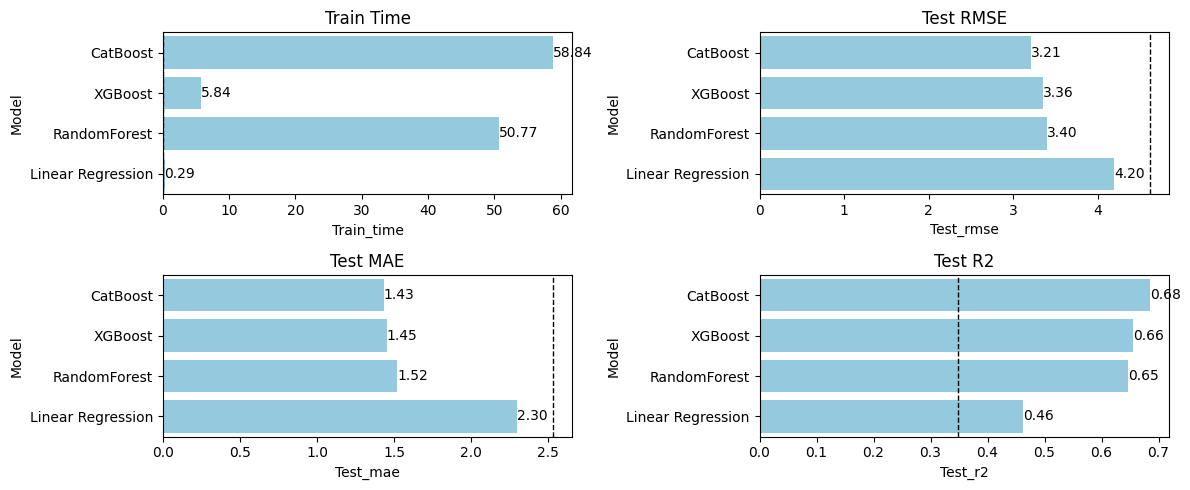

In [58]:
# Plotting of results of new DF.
plot_results(pct_eff_test_sum_model_experiments['results'])

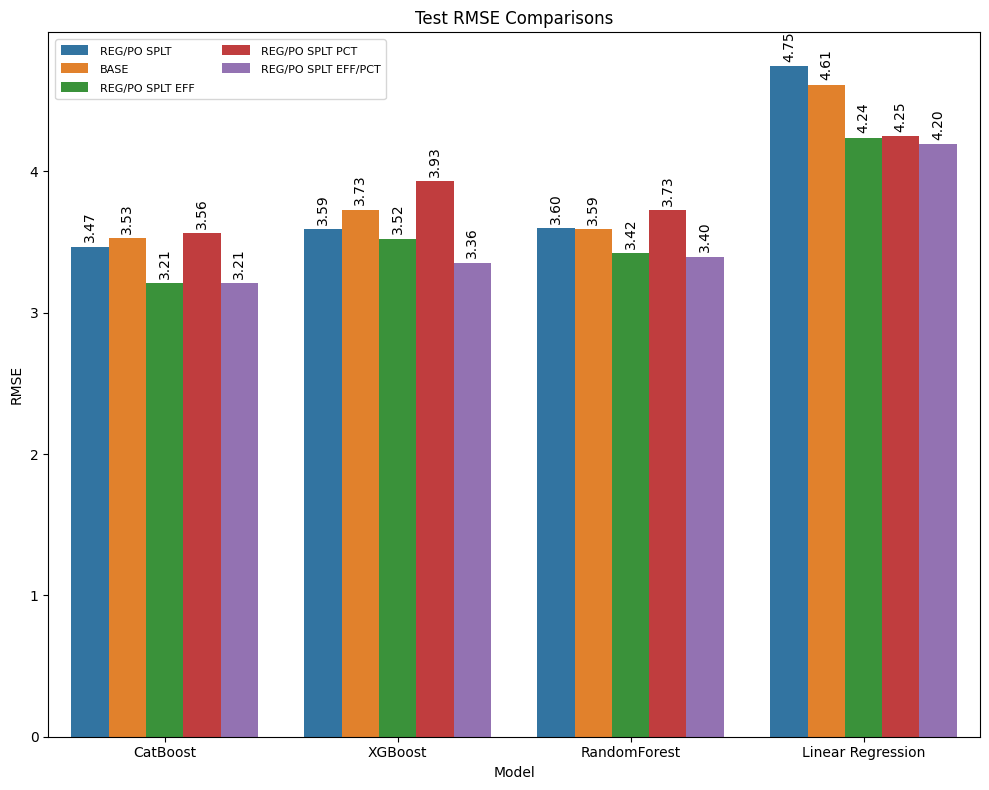

In [59]:
# Adding Results to compilation for comparison.
f_results = pct_eff_test_sum_model_experiments['results']
f_results['Data'] = 'REG/PO SPLT EFF/PCT'
compiled_results = pd.concat([compiled_results, f_results])
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.barplot(data = compiled_results, x = 'Model', y = 'Test_rmse', hue = 'Data')
for container in ax.containers:
  ax.bar_label(container,padding = 3, rotation = 90, fmt = '%.2f')
ax.set_title('Test RMSE Comparisons')
ax.set_ylabel('RMSE')
ax.legend(loc='upper left', ncols=2)
plt.setp(ax.get_legend().get_texts(), fontsize='8')
plt.setp(ax.get_legend().get_title(), fontsize='8')
plt.tight_layout()
plt.show()

In [62]:
# Feature Rankings Summary for 20 of 206
print(f'Total Number of Features : {len(build_feature_summary(pct_eff_test_sum_model_experiments))}')
build_feature_summary(pct_eff_test_sum_model_experiments)[:20]

Total Number of Features : 206


,feature,CatBoost,XGBoost,RandomForest,Linear Regression,Average Rank,Average Importance
0,num__p_yds_pct_reg,5.0,22.0,6.0,2.0,8.75,0.362999
1,num__rec_airyds_pct_reg,2.0,13.0,7.0,27.0,12.25,0.340671
2,num__p_1sts_pct_reg,18.0,35.0,5.0,3.0,15.25,0.269290
3,num__td_int_ratio_reg,1.0,6.0,4.0,63.0,18.50,0.438011
4,num__rec_yds_pct_reg,4.0,5.0,2.0,78.0,22.25,0.401207
5,num__p_ypg_reg,13.0,45.0,16.0,18.0,23.00,0.127058
6,num__att_pct_reg,12.0,2.0,19.0,69.0,25.50,0.203630
7,num__p_yac_pct_reg,22.0,18.0,24.0,49.0,28.25,0.080575
8,num__cmp_pg_reg,14.0,26.0,48.0,33.0,30.25,0.101110
9,num__yds_p_att_reg,37.0,14.0,38.0,53.0,35.50,0.057277


## Cumulative Split with Efficiency and Percentage Models

---
After running our final base models with our final dataframe with both efficiency and percentage metrics, we found that all models across the board improved their performance. CatBoost returned to the same level as the efficiency metrics dataframe alone, while all the other improved ever so slightly.  
These findings are helpful, as we will now look to understand the features and selecting the best subset possible for optimization of our models.


## Feature Selection for Final Model


---
Following our final model runs, we are left with a decision on which features to utilize moving forward. To trial two methods, we will utilize selecting the top 120 average ranking features for all the models, as well as running SelectFromModel on our best performing Model (CatBoostRegressor) in order to get two final feature sets to compare.

### Feature Selection from Final Experimental Runs/ Feature Summary

In [243]:
# Store all features from final run for analysis.
all_features = build_feature_summary(pct_eff_test_sum_model_experiments)
# Select top 120 features based on Average Rank in all Models.
top_120 = all_features[all_features['Average Rank'] < 120]
fts = top_120['feature']
# Clean Up Features to esablish list for new Dataframe.
fts = [f.removeprefix('num__') for f in fts]
for ft in fts:
  if ft.startswith('cat__'):
    fts.remove(ft)

In [229]:
# Keep significant columns aside from numericals
cat_fts = ['position', 'contract_event', 'apy']

# Establish list of all features including those selected form Features Summary.
feats = cat_fts + fts

# Create new Dataframe from final set with top features.
top_ft_df = contract_pct_eff_split_totals[feats]

In [234]:
# Create Feature splits
ft_cat_fts , ft_num_fts = feature_splits(top_ft_df)

# Create Pipelines for testing
top_ft_pipes = {}
for model_name, model in test_models.items():
  top_ft_pipes[model_name] = create_model_pipeline(model, ft_cat_fts, ft_num_fts)

# Run base test models on new dataframe.
top_ft_test_sum_model_experiments = run_model_experiments(top_ft_df, 'apy', ft_cat_fts + ft_num_fts, top_ft_pipes)

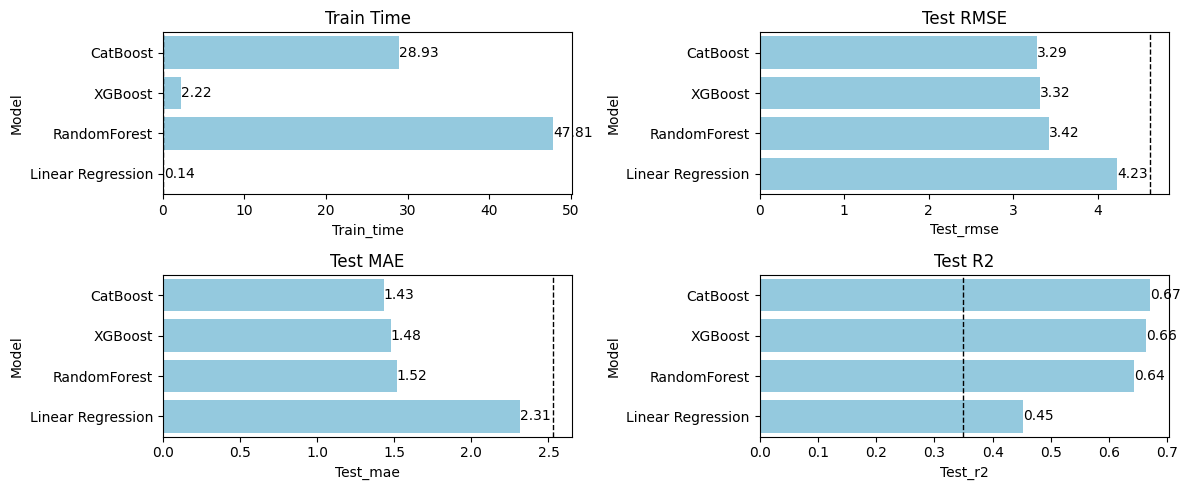

In [238]:
# Plot results from Trainings.
plot_results(top_ft_test_sum_model_experiments['results'])

### SelectFromModel Feature Selections
Utilize CatBoostRegressor for Final Feature set.

In [256]:
# Create Feature and Target set.
X = contract_pct_eff_split_totals.drop(columns=['apy'])
y = contract_pct_eff_split_totals['apy']

# The selector instance
base_selector = SelectFromModel(
    estimator = CatBoostRegressor(iterations = 500, verbose = 0, random_state = 42),
    threshold = 'median')

cats , nums = feature_splits(contract_pct_eff_split_totals)

# Create the full pipeline
selector_pipeline = Pipeline([
    ('preprocessor', create_preprocessor(cats, nums)),
    ('selector', base_selector)]) # Use base_selector here
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Fit and transform using the pipeline
x_selected = selector_pipeline.fit_transform(X_train,y_train)

# Get the selected features from the fitted pipeline's selector step
# First get feature names after preprocessing
preprocessor = selector_pipeline.named_steps['preprocessor']
transformed_feature_names = preprocessor.get_feature_names_out()

# Then get the mask from the selector step
selector_mask = selector_pipeline.named_steps['selector'].get_support()

selected_features = transformed_feature_names[selector_mask]
print(f'Total Features Selected : {len(selected_features)}')

Total Features Selected : 103


In [257]:
# Clean up selected Features for Final DataFrame Creation.
sels = selected_features.copy()
sels  = [f.removeprefix('num__') for f in selected_features]
for ft in sels:
  if ft.startswith('cat__'):
    sels.remove(ft)
sels.remove('cat__contract_event_extension')

In [252]:
# Establish Features and create Dataframe.
features = ['position', 'contract_event', 'apy'] + sels
model_selected_df = contract_pct_eff_split_totals[features]

In [253]:
# Categorical and Numerical Features
model_cat_fts, model_num_fts = feature_splits(model_selected_df)

# Pipes Creation for Test Models.
model_test_pipes = {}
for model_name, model in test_models.items():
  model_test_pipes[model_name] = create_model_pipeline(model, model_cat_fts, model_num_fts)

# Running the training.
model_test_sum_model_experiments = run_model_experiments(model_selected_df, 'apy', model_cat_fts + model_num_fts, model_test_pipes)

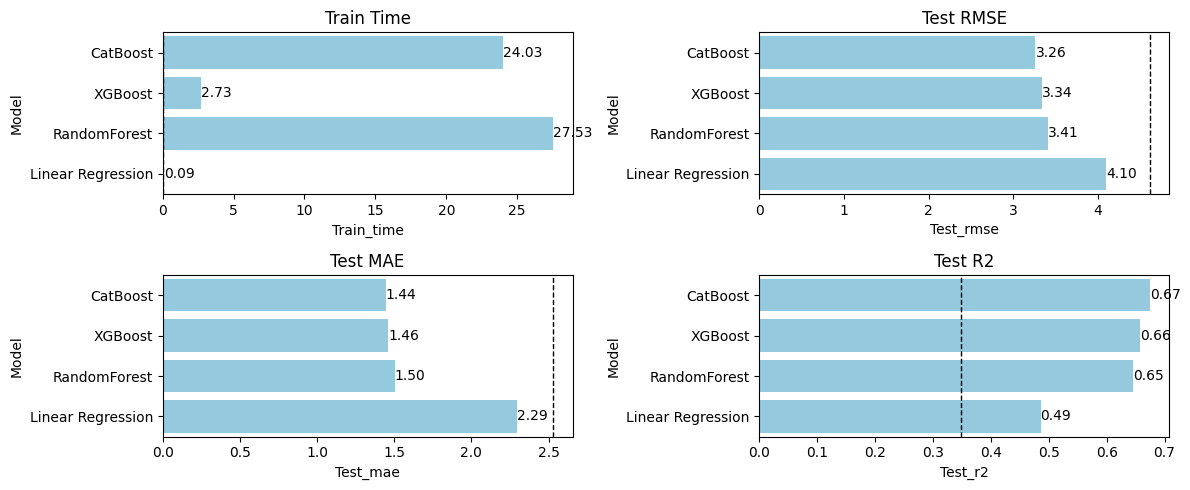

In [254]:
# Plot results from selected features.
plot_results(model_test_sum_model_experiments['results'])

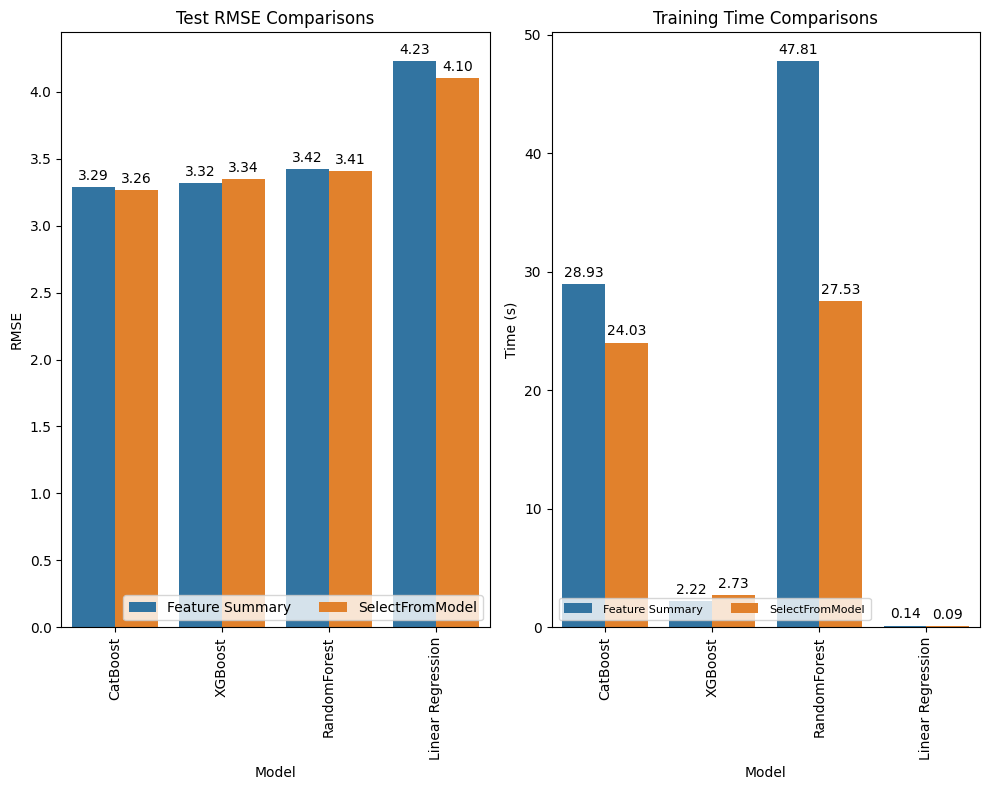

In [267]:
# Compare Metrics
model_results = model_test_sum_model_experiments['results']
feats_results = top_ft_test_sum_model_experiments['results']
model_results['Selection'] = 'SelectFromModel'
feats_results['Selection'] = 'Feature Summary'
comp_results = pd.concat([feats_results, model_results])
fig, ax = plt.subplots(1, 2, figsize=(10, 8))
sns.barplot(data = comp_results, x = 'Model', y = 'Test_rmse', hue = 'Selection', ax = ax[0] )
for container in ax[0].containers:
  ax[0].bar_label(container,padding = 3, fmt = '%.2f')
  ax[0].set_title('Test RMSE Comparisons')
  ax[0].tick_params(axis='x', rotation=90)
  ax[0].set_ylabel('RMSE')
  ax[0].legend(loc='lower right', ncols=2)
sns.barplot(data = comp_results, x = 'Model', y = 'Train_time', hue = 'Selection', ax = ax[1] )
for container in ax[1].containers:
  ax[1].bar_label(container,padding = 3, fmt = '%.2f')
  ax[1].set_title('Training Time Comparisons')
  ax[1].tick_params(axis='x', rotation=90)
  ax[1].set_ylabel('Time (s)')
  ax[1].legend(loc='lower left', ncols=2)
  plt.setp(ax[1].get_legend().get_texts(), fontsize='8')
  plt.setp(ax[1].get_legend().get_title(), fontsize='8')
plt.tight_layout()
plt.show()


In [269]:
# Compare both Features Lists for Overlap
matching = list(set(top_120['feature']) & set(selected_features))

print(f'Feature Selection options had an overlap of {len(matching)} features')

Feature Selection options had an overlap of 91 features


## Feature Selection Findings


---
After selecting the top 120 ranking features from our final experiments as well as running SelectFromModel with our best performing model, we find that the data itself is no longer the bottleneck. Both models did not perform better in regards to accuracy, however the model training time decreased significantly. Performance is a small fee to pay to decrease training time by atleast half.
This points to the final step which is Tuning our Models and seeing if we can get any more performance from them given our data.

# Model Tuning

---
We will now perform somme tuning of the test models with the final data sets in an attempt to improve the model performance. For this, we will be running a GridSearchCV on the linear regression model and RandomizedSearchCV on the remaining models to see how good we can get the models.

In [284]:
#Creating a function for running Randomized and GridSearch experiments.
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

def run_search_experiments(data, target, features, param_grid, model_dict, test_size=0.2,random_state=42):
  # Seperate data between features and target
  X = data[features]
  y = data[target]

  # Establish a test / train split.
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
  # Track results, trained models and store predictions for analysis.
  results = []
  best_models = {}
  # Loop through dictionary of models given.
  for model_name, pipeline in model_dict.items():
    current_pipeline = clone(pipeline)
    if model_name == 'Linear Regression':
      search = GridSearchCV(current_pipeline, param_grid[model_name], cv=5, scoring=rmse_scorer)
    else:
      search = RandomizedSearchCV(current_pipeline, param_grid[model_name], n_iter=5, cv=5, scoring=rmse_scorer, random_state=42)
    # Time training of Model
    start = time.time()
    search.fit(X_train, y_train)
    train_time = time.time() - start

    # Record Best Model & Secure Predictions
    best_model  = search.best_estimator_
    preds = best_model.predict(X_test)

    #RMSE
    test_rmse = root_mean_squared_error(y_test, preds)

    #MAE
    test_mae = mean_absolute_error(y_test, preds)

    #R2
    test_r2 = r2_score(y_test, preds)

    results.append({
        'Model': model_name,
        'CV_RMSE' : -search.best_score_,
        'Best_Params': search.best_params_,
        'Train_time': train_time,
        'Test_rmse': test_rmse,
        'Test_mae': test_mae,
        'Test_r2': test_r2,})

    best_models[model_name] = best_model
    results_df = pd.DataFrame(results)
  results_df = results_df.sort_values(by='Test_rmse', ascending=True)
  return {
      'results' : results_df,
      'models': best_models,
      }

In [285]:
param_grids = {

    "Linear Regression": {
        "regressor__fit_intercept": [True, False],
        "regressor__positive": [False, True]
    },

    "RandomForest": {
        "regressor__n_estimators": [300, 500, 800],
        "regressor__max_depth": [None, 10, 20, 40],
        "regressor__min_samples_split": [2, 5, 10],
        "regressor__min_samples_leaf": [1, 2, 4],
        "regressor__max_features": ["sqrt", "log2", 0.5],
        "regressor__bootstrap": [True]
    },

    "XGBoost": {
        "regressor__n_estimators": [300, 500, 800],
        "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "regressor__max_depth": [3, 5, 7],
        "regressor__subsample": [0.7, 0.85, 1.0],
        "regressor__colsample_bytree": [0.7, 0.85, 1.0],
        "regressor__min_child_weight": [1, 3, 5],
        "regressor__gamma": [0, 0.1, 0.3],
        "regressor__reg_alpha": [0, 0.1, 1],
        "regressor__reg_lambda": [1, 3, 5]
    },

    "CatBoost": {
        "regressor__iterations": [300, 500, 800],
        "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "regressor__depth": [4, 6, 8, 10],
        "regressor__l2_leaf_reg": [1, 3, 5, 7],
        "regressor__bagging_temperature": [0, 1, 3],
        "regressor__random_strength": [1, 3, 5],
        "regressor__border_count": [64, 128, 254]
    }

}

In [286]:
# Categorical and Numerical Features
model_cat_fts, model_num_fts = feature_splits(model_selected_df)

# Pipes Creation for Test Models.
model_test_pipes = {}
for model_name, model in test_models.items():
  model_test_pipes[model_name] = create_model_pipeline(model, model_cat_fts, model_num_fts)

search_cv_selectedfrommodel = run_search_experiments(model_selected_df, 'apy', model_cat_fts + model_num_fts, param_grids, model_test_pipes)

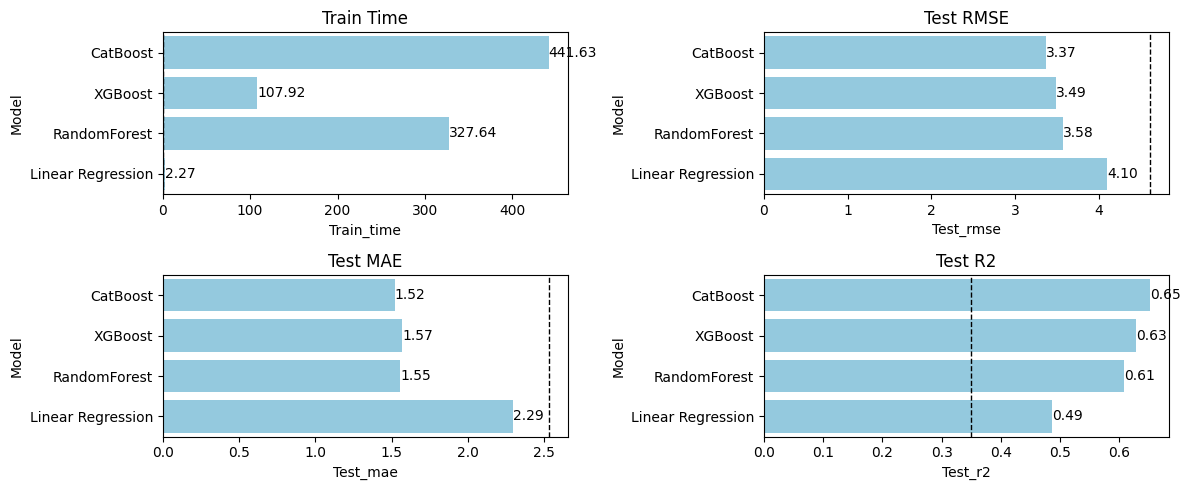

In [288]:
# Plots of results from GridSearch and RandomizedSearchCV
plot_results(search_cv_selectedfrommodel['results'])

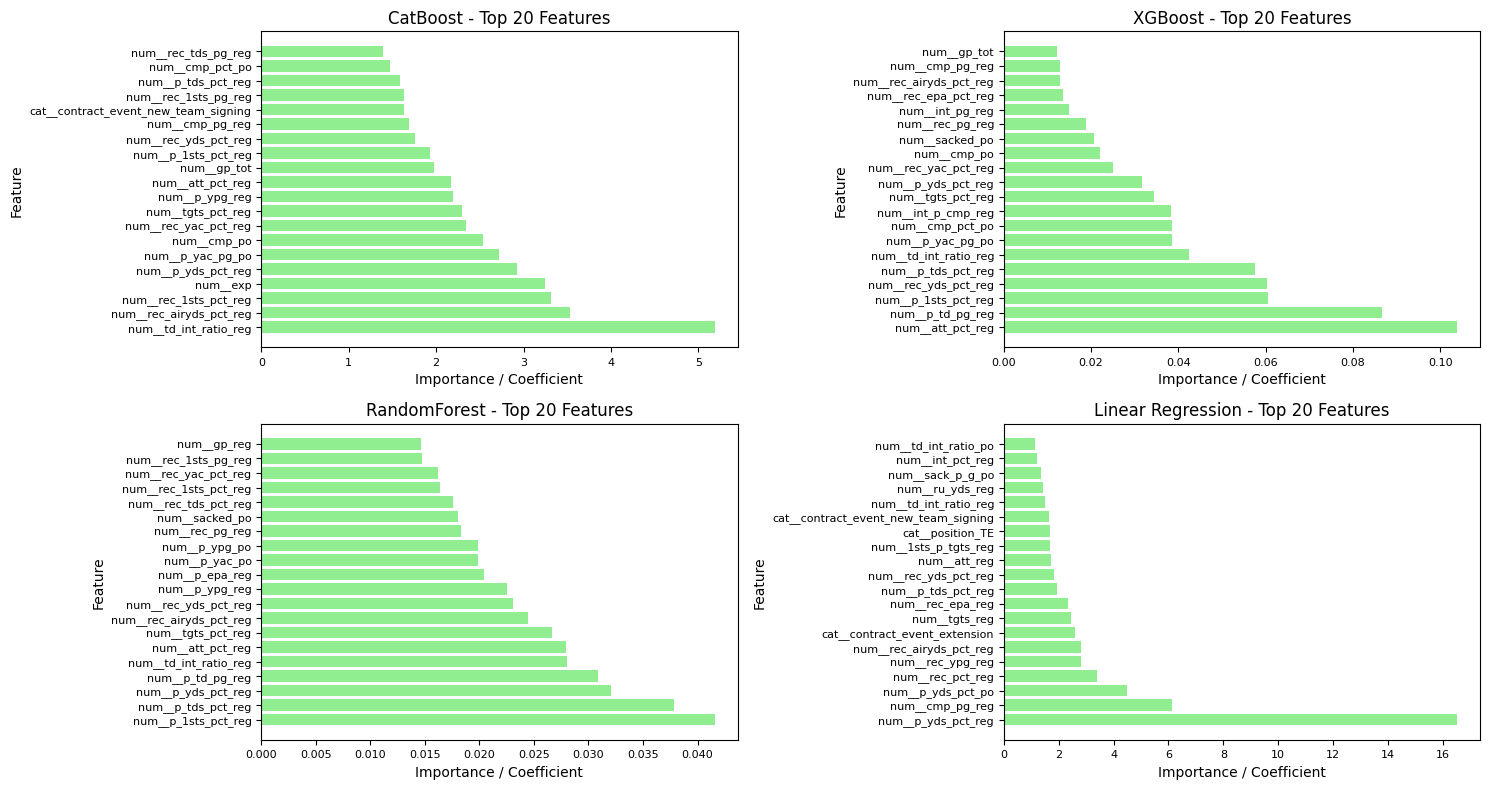

In [289]:
# Plots of Top Features found in each model.
plot_features(search_cv_selectedfrommodel, bottom = False, n = 20)

In [295]:
# Features Summary
print(f'Total Number of Features : {len(build_feature_summary(search_cv_selectedfrommodel))}')
build_feature_summary(search_cv_selectedfrommodel)[:20]

Total Number of Features : 106


,feature,CatBoost,XGBoost,RandomForest,Linear Regression,Average Rank,Average Importance
0,num__p_1sts_pct_reg,13.0,3.0,1.0,2.0,4.75,0.653034
1,num__p_yds_pct_reg,5.0,11.0,3.0,1.0,5.00,0.659447
2,num__att_pct_reg,11.0,1.0,6.0,9.0,6.75,0.587348
3,num__td_int_ratio_reg,1.0,6.0,5.0,24.0,9.00,0.543093
4,num__rec_airyds_pct_reg,2.0,18.0,8.0,13.0,10.25,0.390786
5,num__p_tds_pct_reg,18.0,5.0,2.0,17.0,10.50,0.471994
6,num__rec_yds_pct_reg,14.0,4.0,9.0,18.0,11.25,0.395656
7,num__cmp_pg_reg,15.0,19.0,29.0,3.0,16.50,0.274455
8,num__cmp_po,7.0,13.0,21.0,39.0,20.00,0.274653
9,num__rec_yac_pct_reg,8.0,12.0,18.0,50.0,22.00,0.278265


# Tuning Results


---
After diminishing the features from our final dataframe to those selected by CatBoostRegressor, we find that while the features that were selected held more significance overall, the final model's performance did not improve drastically.

The best model generated from parameter tuning remained the CatBoost Regressor, however the performance diminished predicting APY contract values differing around 3.37 million , as opposed to its best performing model that predicted APY contract values that differed by 3.21 million.

Nonetheless, comparing these results to the baseline model we began with with an RMSE value of 4.61 million for the baseline data, and 4.75 million for the split metrics data, we were able to find a model that was within .2-.3 million off of our initial expectations.

Additionally, we see that a majority of the high Importance features are those that are prominent to the Quarterback position. This is in part due to the values of QB contracts, as they typically are the higher paid athletes on the team.

# Findings, Insights and Next Steps
## Business Understanding
In the NFL, there is no straightforward answer when it comes to a players on field value and the compensation they receive. When contract season comes around, many different factors play into the decision both teams and players must consider for coming to terms on a new contract.  
I aimed to build a model that would help predict fair market value contracts for players, as well as providing them an understanding of the reasons behind such values.  
The model produced aimed to discover what statistical player data can provide insight toward what they should expect in the market.

## Key Findings
The Baseline Linear regression model allowed us to see the overall impact of how we worked the data to improve the models.  

All 3 Models selected to move forward were able to outperform our baseline model, even with the updated datasets applied to the baseline model.

This demonstrates how the relationships between contract values and player statistics is truly non-linear and requires much more thought and consideration to build a good established model.

We were able to achieve 3 models with an RMSE ranging from $3.37 to $3.58 million , telling us that the tree and ensemble models better captured these relationships. Each of the models was able to predict contract APY values that difffered from actual values close to our initial expectations of predicting APY values by $3 million.

## Actionable Items
More reasearch is needed to fully discover which features hold the biggest impact on contract APY's.  

Player positions are key factors, and while building a universal model may not be ideal, Isolating player position by key stats could provide with better models overall.

Allowing more time for tuning of the models could allow for better results, with the current set up, only 5 iterations were ran. Increasing this, while increasing training time could proivde us with better results down the line.

## Recommended Model
I reccomend the XGBoost Model built. For the time of training and the results provided, it is the best model to implement and fine tune. The slightly worse performance is an acceptable trade-off for the time taken to train. Ultimately it would be the best production choice.

## Next Steps
Deploy a production model and track the results, learning from each iteration.

Seek better methods of forming the dataset, accumulation is simple but placing more impact on recent seasons may the key to improving the datasets for models.

Creation of additional features and data is important, aspects such as players winning playoff games, superbowls, NFL awards are all things to be considered and not part of this study.

Continue seeking out new metrics and statistics that are a reflection of players contributions on the teams.

Research and question NFL teams for understandings behind their reasonings on contract valuation. Numbers are not the only aspect that play a factor on a player obtaining a certain contract.

## Future Opportunity.

While the model was trained with Data from all offensive skill positions, there is an opportunity to further divide the data and build models that are specific to each position group.  
There is no single metric or NFL statistic that can cover all positional values, and each individual provides a unique skillset and output on the field for everyone's team overall.